In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files
import os
import seaborn as sns
import matplotlib.colors as mcolors
import glob
from collections import Counter

In [2]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
cd gdrive/MyDrive/finalized_data

/content/gdrive/MyDrive/finalized_data


In [61]:
df1 = pd.read_csv("Station1_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df2 = pd.read_csv("Station2_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df3 = pd.read_csv("Station3_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df4 = pd.read_csv("Station4_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df5 = pd.read_csv("Station5_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')
df6 = pd.read_csv("Station6_simulated_cleaned_merged_data.csv", sep = ",", parse_dates = ['Unnamed: 0'], index_col = 'Unnamed: 0')

df1.index = pd.to_datetime(df1.index)
df2.index = pd.to_datetime(df2.index)
df3.index = pd.to_datetime(df3.index)
df4.index = pd.to_datetime(df4.index)
df5.index = pd.to_datetime(df5.index)
df6.index = pd.to_datetime(df6.index)

In [62]:
dfList = [df1, df2, df3, df4, df5, df6]
labels = ['df1', 'df2', 'df3', 'df4', 'df5', 'df6']

In [63]:
features = ['SWC_5','SWC_10','SWC_20','SWC_50', 'Ppt']
feature_tables = []

for i in range(1, 7):
  feature_table = pd.DataFrame(index = dfList[i - 1].index)

  for j, df in enumerate(dfList, start = 1):
      for feature in features:
        if (j == i):
          new_feature_name = f"{feature}_Station{j}"
          feature_table[new_feature_name] = df[feature]

  # create new feature table with 240-step (10-day) moving averages
  # first 239 records for each feature are computed using expanding mean (i.e. mean of all records up until current record)

  for feature in feature_table.columns:
    expanding_mean = feature_table[feature].expanding().mean()
    rolling_mean = feature_table[feature].rolling(window = 240).mean()
    combined_mean = rolling_mean.fillna(expanding_mean) # first (window - 1) records are filled with expanding_mean values
    feature_table[feature] = combined_mean

  feature_tables.append(feature_table)

In [64]:
corr_features = ['SWC_5','SWC_10','SWC_20','SWC_50','Ppt','T_5','T_10','T_20','T_50','Srad','Tair','RH','Windspeed','Winddirection']
corr_feature_tables = []

for i in range(1, 7):
  corr_feature_table = pd.DataFrame(index = dfList[i - 1].index)

  for j, df in enumerate(dfList, start = 1):
      for corr_feature in corr_features:
        if (j == i):
          new_feature_name = f"{corr_feature}_Station{j}"
          corr_feature_table[new_feature_name] = df[corr_feature]

  # create new feature table with 240-step (10-day) moving averages
  # first 239 records for each feature are computed using expanding mean (i.e. mean of all records up until current record)

  for corr_feature in corr_feature_table.columns:
    expanding_mean = corr_feature_table[corr_feature].expanding().mean()
    rolling_mean = corr_feature_table[corr_feature].rolling(window = 240).mean()
    combined_mean = rolling_mean.fillna(expanding_mean) # first (window - 1) records are filled with expanding_mean values
    corr_feature_table[corr_feature] = combined_mean

  corr_feature_tables.append(corr_feature_table)

In [65]:
# helper function to create sequences from the data
def create_sequences(data, n_steps, step_size):
    X = []
    start_indices = []
    for i in range(0, len(data) - n_steps, step_size):
        X.append(data[i:i+n_steps])
        start_indices.append(i)
    return np.array(X), np.array(start_indices)

In [8]:
def normalize_data(data):
    # normalize each feature to value betweeen 0 and 1
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(data.reshape(-1, 1))
    return scaled_data, scaler

In [9]:
# original time series and anomaly visualization
def original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name):
  plt.figure(figsize = (15, 6))
  plt.plot(df.index, original_data, label = 'Original Data', color = 'blue', alpha = 0.5)
  if len(anomaly_indices) > 0:
      plt.scatter(anomaly_dates, anomaly_values, color = 'red', label = 'Anomaly', alpha = 0.75)
  plt.xlabel('Date')
  plt.ylabel(feature_name)
  plt.title(f'{feature_name} Data and Detected Anomalies')
  plt.legend()
  plt.show()

In [10]:
# autoencoder reconstruction visualization
def autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates):
    plt.figure(figsize = (15, 6))
    plt.plot(plot_dates, reconstructed_data, label = 'Reconstructed Data', color = 'orange', alpha = 0.75)
    plt.xlabel('Date')
    plt.ylabel('Reconstructed Value')
    plt.title(f'Reconstructed {feature_name} Over Time')
    plt.legend()
    plt.show()

In [11]:
# original time series, anomaly, & autoencoder reconstruction visualization
def anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates):
    plt.figure(figsize = (15, 6))
    plt.plot(df.index, original_data, label = 'Original Data', color = 'blue', alpha = 0.5)
    plt.plot(plot_dates, reconstructed_data, label = 'Reconstructed Data', color = 'orange', alpha = 0.75)
    if len(anomaly_indices) > 0:
        plt.scatter(anomaly_dates, anomaly_values, color = 'red', label = 'Anomaly', alpha = 0.75)
    plt.xlabel('Date')
    plt.ylabel(feature_name)
    plt.title(f'Reconstruction and Anomalies for {feature_name}')
    plt.legend()
    plt.show()

In [12]:
# original time series, graded anomalies, & autoencoder reconstruction visualization
def graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates):
    plt.figure(figsize = (15, 6))
    plt.plot(df.index, original_data, label = 'Original Data', color = 'blue', alpha = 0.5)
    plt.plot(plot_dates, reconstructed_data, label = 'Reconstructed Data', color = 'orange', alpha = 0.75)
    if len(anomaly_indices) > 0:
      plt.scatter(anomaly_dates, anomaly_values, c = reconstruction_error[anomaly_indices], cmap = 'winter', label = 'Anomaly', alpha = 0.75)
    plt.colorbar(label = 'Anomaly Strength (Reconstruction Error)')
    plt.xlabel('Date')
    plt.ylabel(feature_name)
    plt.title(f'Reconstruction and Graded Anomalies for {feature_name}')
    plt.legend()
    plt.show()

# Precipitation Anomaly Detection - 10 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 240, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_10_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'Ppt_Station' + str(i + 1))

In [ ]:
train_visualize(feature_tables[5], 'Ppt_Station' + str(5 + 1))

# Precipitation Anomaly Detection - 7 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 168, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_7_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'Ppt_Station' + str(i + 1))

In [ ]:
train_visualize(feature_tables[4], 'Ppt_Station' + str(4 + 1))

In [ ]:
train_visualize(feature_tables[5], 'Ppt_Station' + str(5 + 1))

# Precipitation Anomaly Detection - 3 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 72, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_3_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'Ppt_Station' + str(i + 1))

# Precipitation Anomaly Detection - 2 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 48, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_2_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'Ppt_Station' + str(i + 1))

In [ ]:
train_visualize(feature_tables[5], 'Ppt_Station' + str(5 + 1))

# Precipitation Anomaly Detection - 1 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 24, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_1_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'Ppt_Station' + str(i + 1))

# SWC_5 Anomaly Detection - 10 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 240, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_10_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'SWC_5_Station' + str(i + 1))

# SWC_5 Anomaly Detection - 7 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 168, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_7_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'SWC_5_Station' + str(i + 1))

# SWC_5 Anomaly Detection - 3 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 72, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_3_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'SWC_5_Station' + str(i + 1))

# SWC_5 Anomaly Detection - 2 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 48, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_2_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'SWC_5_Station' + str(i + 1))

# SWC_5 Anomaly Detection - 1 Day Window #

In [ ]:
# 10-day sequences, 1-day steps
def train_visualize(df, feature_name, n_steps = 24, epochs = 100, batch_size = 128, step_size = 24):
    feature_data = df[feature_name].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range = (0, 1))
    scaled_data = scaler.fit_transform(feature_data)

    # store start_indices for visualizations
    X, start_indices = create_sequences(scaled_data, n_steps = n_steps, step_size = step_size)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # LSTM autoencoder model
    model = Sequential([
        Bidirectional(LSTM(128, activation = 'relu', input_shape = (n_steps, 1), return_sequences = True)),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = False)),
        RepeatVector(n_steps),
        Bidirectional(LSTM(64, activation = 'relu', return_sequences = True)),
        Bidirectional(LSTM(128, activation = 'relu', return_sequences = True)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer = Adam(learning_rate = 0.00002), loss = 'mse')

    # stop training when performance plateaus
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 20, mode = 'min', verbose = 1, restore_best_weights = True)
    history = model.fit(X, X, epochs = epochs, batch_size = batch_size, validation_split = 0.2, shuffle = True, callbacks = [early_stopping])

    X_pred = model.predict(X)
    reconstruction_error = np.mean(np.abs(X_pred - X), axis = 1).flatten()

    # threshold for anomaly detection
    threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)
    anomalies = reconstruction_error > threshold

    # mapping sequences back to dates
    end_indices = start_indices + n_steps - 1
    plot_dates = df.index[end_indices]
    original_data = scaler.inverse_transform(scaled_data).flatten()
    anomaly_indices = np.where(anomalies)[0]
    anomaly_dates = plot_dates[anomaly_indices]
    anomaly_values = original_data[end_indices[anomaly_indices]]

    # original time series and anomaly visualization
    original_anomaly_plot(df, original_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name)

    # autoencoder reconstruction visualization
    reconstructed_data = scaler.inverse_transform(X_pred[:, -1, :]).flatten()
    autoencoder_reconstruction_plot(df, reconstructed_data, feature_name, plot_dates)

    # original time series, anomaly, & autoencoder reconstruction visualization
    anomaly_reconstruction_plot(df, original_data, reconstructed_data, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    # original time series, graded anomalies, & autoencoder reconstruction visualization
    graded_anomaly_plot(df, original_data, reconstructed_data, reconstruction_error, anomaly_indices, anomaly_dates, anomaly_values, feature_name, plot_dates)

    formatted_anomaly_dates = [date.strftime('%m-%d-%Y') for date in anomaly_dates]
    anomaly_dates_df = pd.DataFrame(formatted_anomaly_dates, columns = ['Anomaly Dates'])
    file_name = f'{feature_name}_1_Day_Window_Anomaly_Dates.csv'
    anomaly_dates_df.to_csv(file_name, index = False)

In [ ]:
for i in range(len(feature_tables)):
  train_visualize(feature_tables[i], 'SWC_5_Station' + str(i + 1))

# Precipitation Anomaly Analysis #

In [43]:
# get all CSV files in the current directory with the correct pattern
csv_files = glob.glob('Ppt_Station*_Day_Window_Anomaly_Dates.csv')

# dictionary to store dates for each station and window size
date_sets = {}

# read each CSV and extract dates
for file_path in csv_files:
    # extract station and window size from file name
    file_name = file_path
    parts = file_name.split('_')
    station = int(parts[1][7:])  # Station number follows 'Station' which is 7 characters long
    window_size = int(parts[2])  # Extracting window size from the correct part of the filename

    data = pd.read_csv(file_path)

    if 'Anomaly Dates' in data.columns:
        dates = set(data['Anomaly Dates'])  # convert list of dates to a set for intersection

        # store dates in dictionary with key as tuple (station, window size)
        if (station, window_size) not in date_sets:
            date_sets[(station, window_size)] = dates
        else:
            date_sets[(station, window_size)].intersection_update(dates)
    else:
        print("Anomaly Dates column not found in", file_path)

date_frequencies = {}

# calculate frequency of each date across window sizes for each station
for station in range(1, 7):
    # combine all dates from all window sizes for this station
    combined_dates = []
    for window_size in [1, 2, 3, 7, 10]:
        combined_dates.extend(date_sets.get((station, window_size), []))

    # count frequency of each date
    frequency = pd.Series(combined_dates).value_counts()

    # sort dates by frequency in descending order
    sorted_dates = frequency.sort_values(ascending=False)

    # store in dictionary
    date_frequencies[station] = sorted_dates

In [44]:
# print results
for station, frequencies in date_frequencies.items():
    print(f"Station {station}:")
    for date, count in frequencies.items():
        print(f"  Date: {date}, Count: {count}")

Station 1:
  Date: 05-02-2021, Count: 5
  Date: 10-27-2018, Count: 5
  Date: 10-18-2018, Count: 5
  Date: 10-17-2018, Count: 5
  Date: 05-09-2019, Count: 4
  Date: 11-06-2016, Count: 4
  Date: 09-15-2018, Count: 4
  Date: 10-28-2018, Count: 4
  Date: 11-07-2016, Count: 4
  Date: 11-13-2016, Count: 4
  Date: 08-16-2016, Count: 4
  Date: 08-17-2017, Count: 4
  Date: 09-20-2020, Count: 4
  Date: 09-10-2020, Count: 4
  Date: 09-20-2018, Count: 4
  Date: 08-08-2017, Count: 4
  Date: 05-26-2020, Count: 4
  Date: 11-17-2016, Count: 4
  Date: 12-17-2016, Count: 4
  Date: 11-16-2016, Count: 4
  Date: 08-18-2017, Count: 4
  Date: 10-26-2018, Count: 4
  Date: 08-07-2017, Count: 4
  Date: 09-11-2020, Count: 4
  Date: 05-03-2021, Count: 4
  Date: 09-11-2018, Count: 4
  Date: 09-10-2018, Count: 4
  Date: 05-27-2020, Count: 3
  Date: 12-18-2018, Count: 3
  Date: 08-17-2016, Count: 3
  Date: 09-21-2020, Count: 3
  Date: 12-18-2016, Count: 3
  Date: 11-14-2016, Count: 3
  Date: 07-21-2021, Count: 3
  D

In [45]:
finalList = [[], [], [], [], [], []]

# print the dates with the highest frequency for each station
for station, frequencies in date_frequencies.items():
    print(f"Station {station}:")
    max_frequency = frequencies.max()
    for date, count in frequencies.items():
        if count == max_frequency:
            print(f"  Date: {date}, Count: {count}")
            finalList[station - 1].append(date)

# write each station's maximum frequency anomaly dates to a CSV file
for i, dates in enumerate(finalList):
    station_number = i + 1
    file_name = f"Ppt_Station_{station_number}_High_Frequency_Anomalies.csv"
    df = pd.DataFrame(dates, columns = ['High Frequency Anomaly Dates'])
    df.to_csv(file_name, index = False)

Station 1:
  Date: 05-02-2021, Count: 5
  Date: 10-27-2018, Count: 5
  Date: 10-18-2018, Count: 5
  Date: 10-17-2018, Count: 5
Station 2:
  Date: 08-07-2017, Count: 5
  Date: 05-13-2019, Count: 5
  Date: 06-02-2016, Count: 5
  Date: 05-25-2020, Count: 5
  Date: 11-03-2015, Count: 5
  Date: 05-18-2019, Count: 5
Station 3:
  Date: 05-08-2019, Count: 5
  Date: 05-13-2019, Count: 5
  Date: 10-24-2015, Count: 5
  Date: 05-18-2019, Count: 5
Station 4:
  Date: 11-03-2015, Count: 5
  Date: 10-17-2018, Count: 5
  Date: 08-17-2017, Count: 5
  Date: 10-18-2018, Count: 5
  Date: 11-07-2015, Count: 5
  Date: 10-16-2018, Count: 5
  Date: 11-13-2016, Count: 5
  Date: 10-26-2018, Count: 5
Station 5:
  Date: 11-03-2015, Count: 5
  Date: 10-31-2015, Count: 5
  Date: 05-29-2015, Count: 5
  Date: 07-06-2021, Count: 5
  Date: 09-19-2020, Count: 5
Station 6:
  Date: 10-17-2018, Count: 5
  Date: 05-30-2015, Count: 5
  Date: 10-25-2018, Count: 5
  Date: 10-16-2018, Count: 5
  Date: 10-26-2018, Count: 5


In [46]:
set_list = [set(lst) for lst in finalList]
common_dates_all = set.intersection(*set_list)
print("Dates appearing in all stations:", common_dates_all)

flat_list = [date for sublist in finalList for date in sublist]
date_counts = Counter(flat_list)

common_dates_multiple = {date: count for date, count in date_counts.items() if count > 1 and date not in common_dates_all}
print("Dates appearing in multiple stations and their counts:", common_dates_multiple)

data_for_csv = [
    {'Type': 'Common in All Stations', 'Date': date, 'Count': len(finalList)} for date in common_dates_all
] + [
    {'Type': 'Common in Multiple Stations', 'Date': date, 'Count': count} for date, count in common_dates_multiple.items()
]

df = pd.DataFrame(data_for_csv)
csv_filename = 'Ppt_Common_Dates_Across_Stations.csv'
df.to_csv(csv_filename, index=False)
print(f"Common dates across stations have been written to {csv_filename}")

Dates appearing in all stations: set()
Dates appearing in multiple stations and their counts: {'10-18-2018': 2, '10-17-2018': 3, '05-13-2019': 2, '11-03-2015': 3, '05-18-2019': 2, '10-16-2018': 2, '10-26-2018': 2}
Common dates across stations have been written to Ppt_Common_Dates_Across_Stations.csv


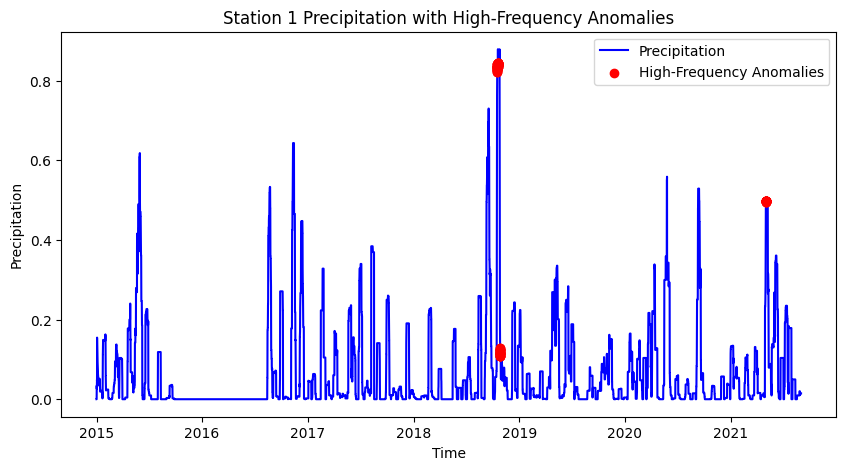

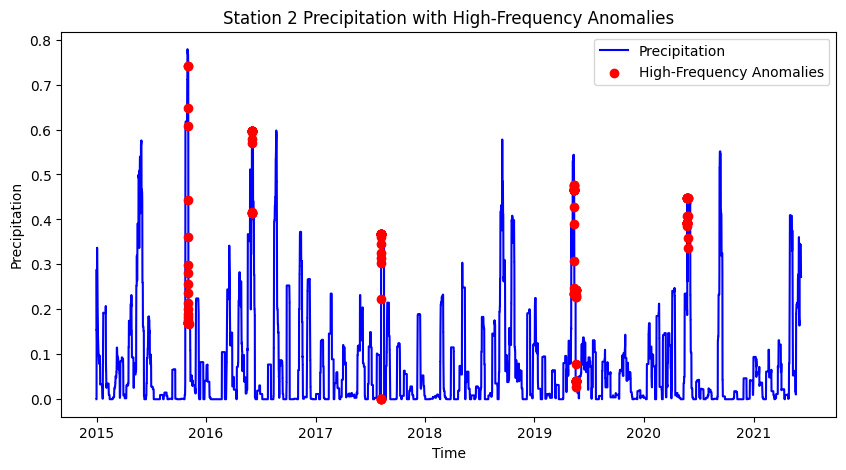

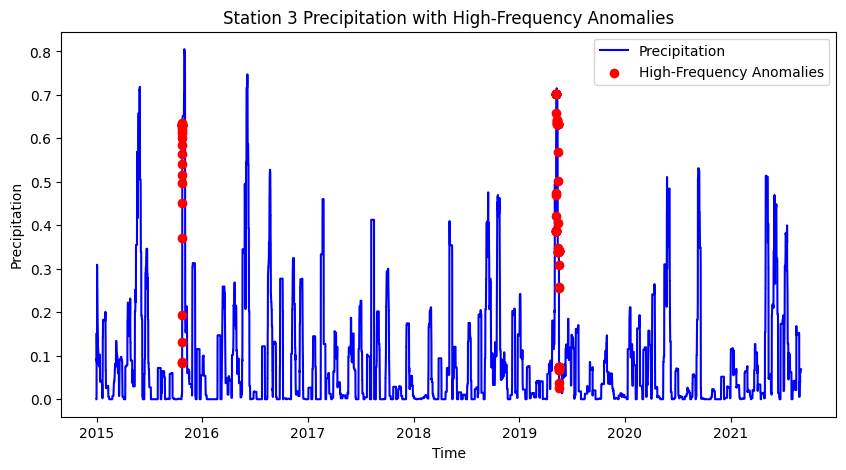

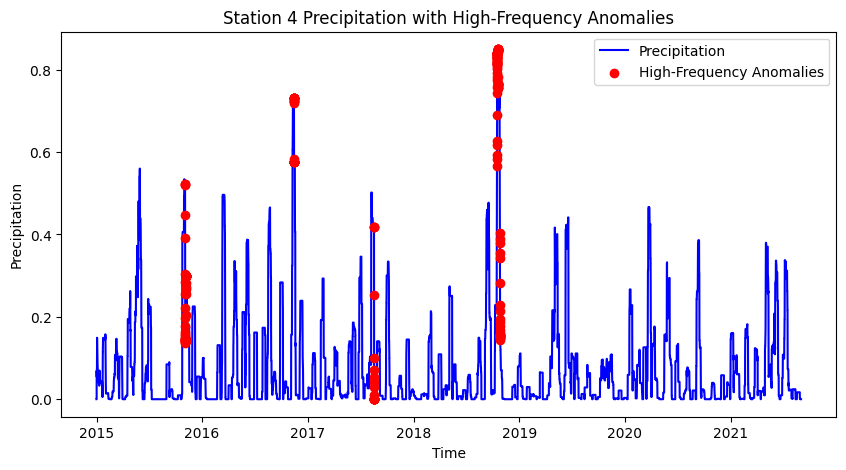

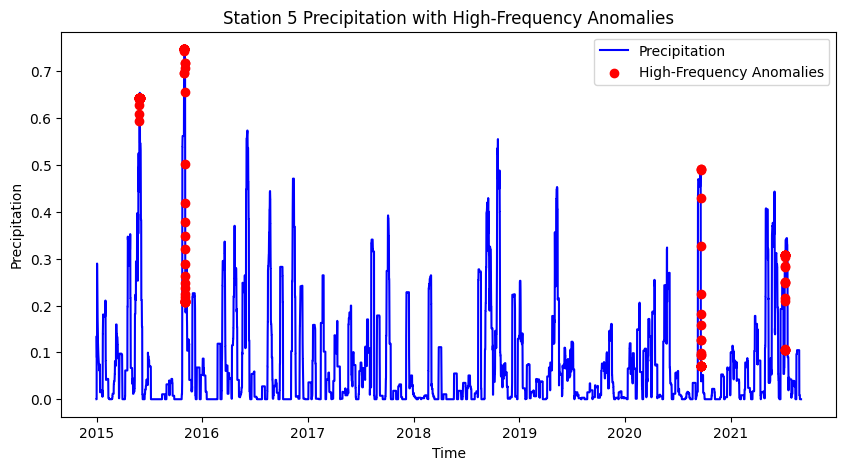

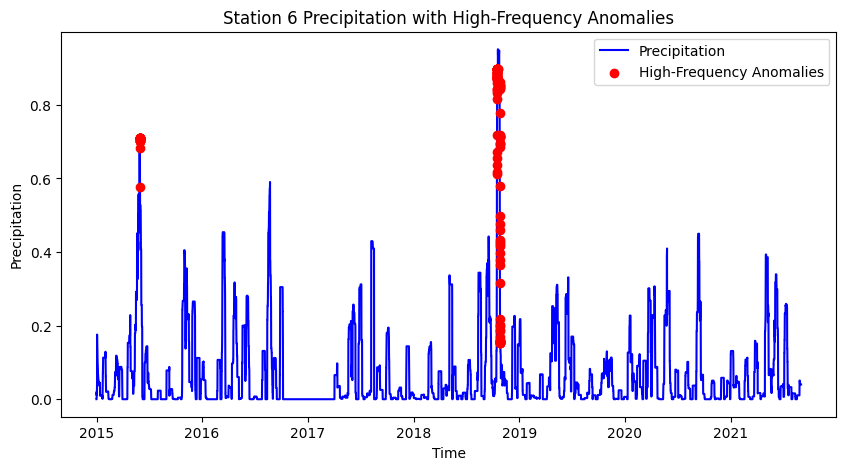

In [47]:
# plotting the original precipitation data and highlighting anomalies
for i, df in enumerate(feature_tables):
    station_number = i + 1
    plt.figure(figsize = (10, 5))

    # convert anomaly dates from strings to datetime objects for comparison
    anomaly_dates = pd.to_datetime(finalList[i], errors = 'coerce').normalize()

    # convert DataFrame index to normalized datetime for proper comparison
    df_index_normalized = df.index.normalize()

    # find indices where the anomalies occur
    anomaly_indices = df_index_normalized.isin(anomaly_dates)

    # Plot the precipitation data
    plt.plot(df.index, df['Ppt_Station' + str(station_number)], label = 'Precipitation', linestyle = '-', marker = '', color = 'blue')

    # Highlight anomalies
    plt.scatter(df.index[anomaly_indices], df['Ppt_Station' + str(station_number)][anomaly_indices], color = 'red', label = 'High-Frequency Anomalies', zorder = 5)

    # Plot setup
    plt.title(f'Station {station_number} Precipitation with High-Frequency Anomalies')
    plt.xlabel('Time')
    plt.ylabel('Precipitation')
    plt.legend()
    plt.show()

# SWC_5 Anomaly Analysis #

In [48]:
import pandas as pd
import glob

# get all CSV files in the current directory with the correct pattern
csv_files = glob.glob('SWC_5_Station*_Day_Window_Anomaly_Dates.csv')

# dictionary to store dates for each station and window size
date_sets = {}

# read each CSV and extract dates
for file_path in csv_files:
    # extract station and window size from file name
    file_name = file_path
    parts = file_name.split('_')
    station = int(parts[2].replace('Station', ''))  # extracting station number
    window_size = int(parts[3])  # extracting window size

    data = pd.read_csv(file_path)

    if 'Anomaly Dates' in data.columns:
        dates = set(data['Anomaly Dates'])  # convert list of dates to a set for intersection

        # store dates in dictionary with key as tuple (station, window size)
        if (station, window_size) not in date_sets:
            date_sets[(station, window_size)] = dates
        else:
            date_sets[(station, window_size)].intersection_update(dates)
    else:
        print("Anomaly Dates column not found in", file_path)

date_frequencies = {}

# calculate frequency of each date across window sizes for each station
for station in range(1, 7):
    # combine all dates from all window sizes for this station
    combined_dates = []
    for window_size in [1, 2, 3, 7, 10]:
        combined_dates.extend(date_sets.get((station, window_size), []))

    # count frequency of each date
    frequency = pd.Series(combined_dates).value_counts()

    # sort dates by frequency in descending order
    sorted_dates = frequency.sort_values(ascending=False)

    # store in dictionary
    date_frequencies[station] = sorted_dates

In [49]:
# print results
for station, frequencies in date_frequencies.items():
    print(f"Station {station}:")
    for date, count in frequencies.items():
        print(f"  Date: {date}, Count: {count}")

Station 1:
  Date: 02-22-2021, Count: 5
  Date: 08-15-2016, Count: 5
  Date: 09-10-2018, Count: 5
  Date: 08-16-2016, Count: 5
  Date: 05-02-2021, Count: 4
  Date: 08-23-2016, Count: 4
  Date: 10-27-2015, Count: 4
  Date: 10-26-2015, Count: 4
  Date: 09-07-2020, Count: 4
  Date: 06-27-2017, Count: 4
  Date: 09-15-2020, Count: 4
  Date: 09-14-2020, Count: 4
  Date: 09-11-2020, Count: 4
  Date: 09-18-2018, Count: 4
  Date: 09-10-2020, Count: 4
  Date: 08-15-2018, Count: 4
  Date: 11-03-2015, Count: 4
  Date: 08-09-2017, Count: 4
  Date: 11-09-2016, Count: 3
  Date: 09-07-2018, Count: 3
  Date: 09-05-2020, Count: 3
  Date: 10-04-2017, Count: 3
  Date: 10-02-2017, Count: 3
  Date: 10-25-2015, Count: 3
  Date: 09-06-2017, Count: 3
  Date: 09-06-2020, Count: 3
  Date: 09-13-2020, Count: 3
  Date: 02-21-2018, Count: 3
  Date: 10-24-2015, Count: 3
  Date: 05-19-2016, Count: 3
  Date: 11-10-2016, Count: 3
  Date: 09-12-2018, Count: 3
  Date: 06-14-2021, Count: 3
  Date: 07-01-2017, Count: 3
  D

In [50]:
finalList = [[], [], [], [], [], []]

# print the dates with the highest frequency for each station
for station, frequencies in date_frequencies.items():
    print(f"Station {station}:")
    max_frequency = frequencies.max()
    for date, count in frequencies.items():
        if count == max_frequency:
            print(f"  Date: {date}, Count: {count}")
            finalList[station - 1].append(date)

# write each station's maximum frequency anomaly dates to a CSV file
for i, dates in enumerate(finalList):
    station_number = i + 1
    file_name = f"SWC_5_Station_{station_number}_High_Frequency_Anomalies.csv"
    df = pd.DataFrame(dates, columns = ['High Frequency Anomaly Dates'])
    df.to_csv(file_name, index = False)

Station 1:
  Date: 02-22-2021, Count: 5
  Date: 08-15-2016, Count: 5
  Date: 09-10-2018, Count: 5
  Date: 08-16-2016, Count: 5
Station 2:
  Date: 10-27-2015, Count: 5
Station 3:
  Date: 08-15-2016, Count: 5
  Date: 08-24-2016, Count: 5
  Date: 10-26-2015, Count: 5
Station 4:
  Date: 10-27-2015, Count: 5
  Date: 09-09-2018, Count: 5
  Date: 09-14-2020, Count: 5
  Date: 10-29-2015, Count: 5
  Date: 09-11-2020, Count: 5
  Date: 10-31-2015, Count: 5
  Date: 08-18-2016, Count: 5
  Date: 09-07-2020, Count: 5
  Date: 09-08-2020, Count: 5
  Date: 09-10-2018, Count: 5
  Date: 10-02-2017, Count: 5
  Date: 10-26-2015, Count: 5
  Date: 08-17-2016, Count: 5
  Date: 09-11-2018, Count: 5
  Date: 08-16-2016, Count: 5
  Date: 09-10-2020, Count: 5
  Date: 09-09-2020, Count: 5
  Date: 10-28-2015, Count: 5
  Date: 10-01-2017, Count: 5
  Date: 11-01-2015, Count: 5
  Date: 10-30-2015, Count: 5
Station 5:
  Date: 10-29-2015, Count: 5
  Date: 11-10-2016, Count: 5
  Date: 09-09-2018, Count: 5
  Date: 10-31-201

In [51]:
set_list = [set(lst) for lst in finalList]
common_dates_all = set.intersection(*set_list)
print("Dates appearing in all stations:", common_dates_all)

flat_list = [date for sublist in finalList for date in sublist]
date_counts = Counter(flat_list)

common_dates_multiple = {date: count for date, count in date_counts.items() if count > 1 and date not in common_dates_all}
print("Dates appearing in multiple stations and their counts:", common_dates_multiple)

data_for_csv = [
    {'Type': 'Common in All Stations', 'Date': date, 'Count': len(finalList)} for date in common_dates_all
] + [
    {'Type': 'Common in Multiple Stations', 'Date': date, 'Count': count} for date, count in common_dates_multiple.items()
]

df = pd.DataFrame(data_for_csv)
csv_filename = 'SWC_5_Common_Dates_Across_Stations.csv'
df.to_csv(csv_filename, index=False)
print(f"Common dates across stations have been written to {csv_filename}")

Dates appearing in all stations: set()
Dates appearing in multiple stations and their counts: {'08-15-2016': 3, '09-10-2018': 3, '08-16-2016': 3, '10-27-2015': 2, '10-26-2015': 2, '09-09-2018': 2, '10-29-2015': 2, '10-31-2015': 2, '08-18-2016': 2, '10-02-2017': 2, '08-17-2016': 2, '10-28-2015': 2, '10-01-2017': 2, '10-30-2015': 2}
Common dates across stations have been written to SWC_5_Common_Dates_Across_Stations.csv


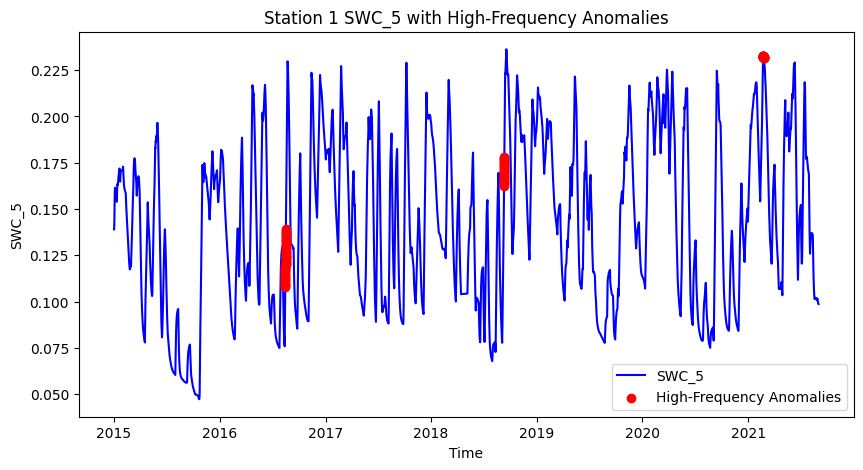

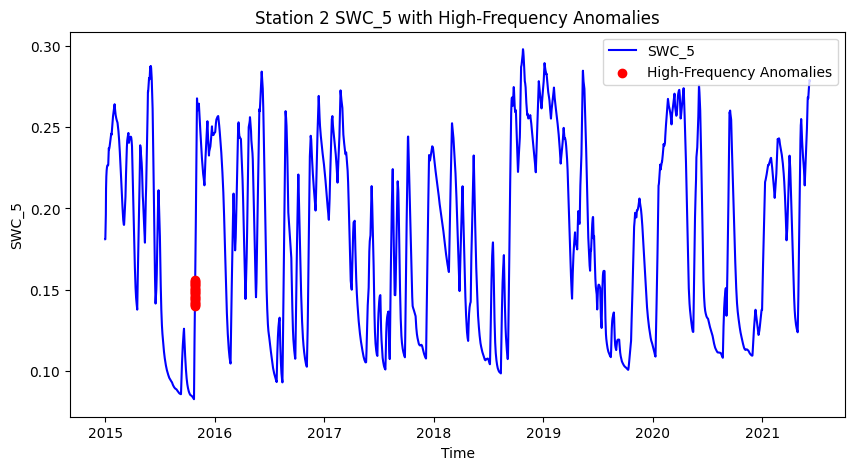

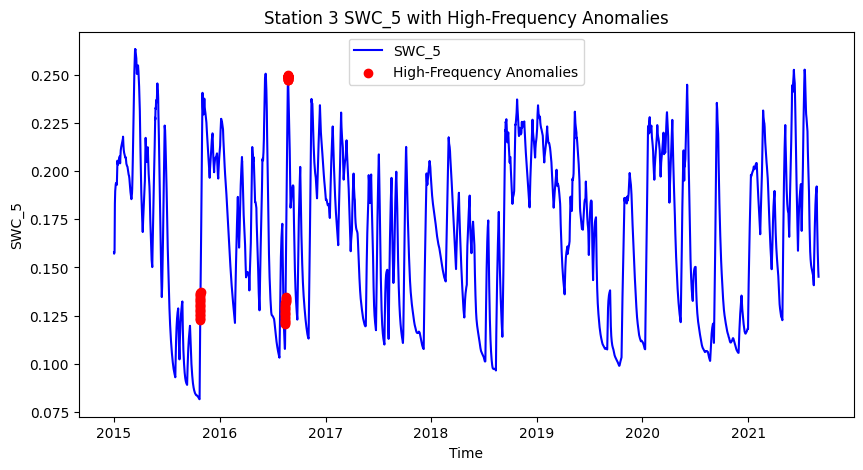

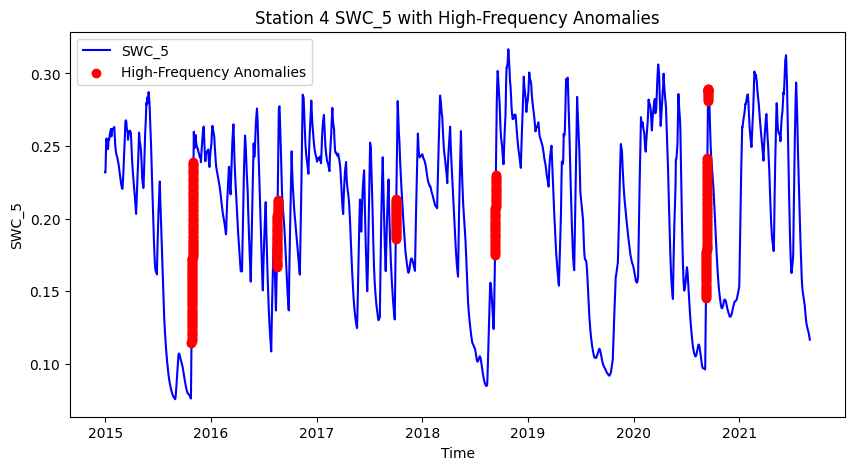

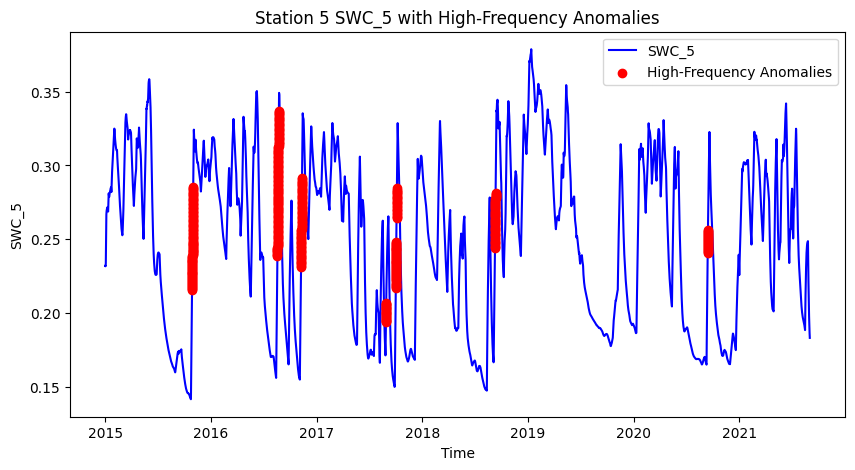

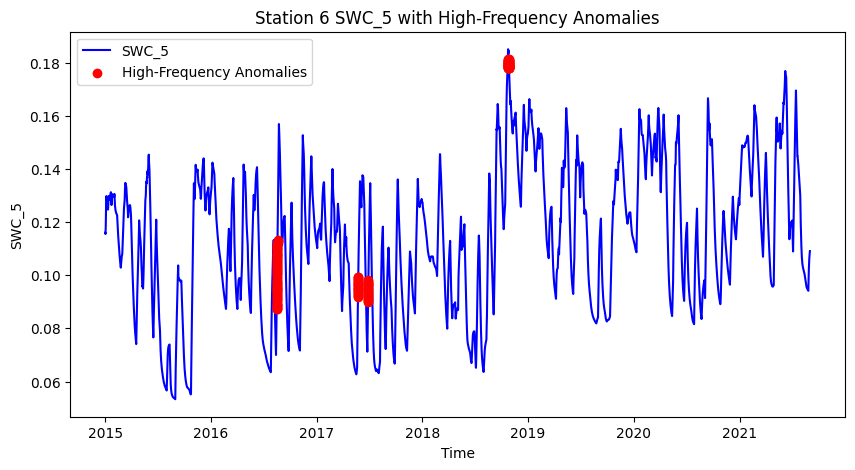

In [52]:
# plotting the original precipitation data and highlighting anomalies
for i, df in enumerate(feature_tables):
    station_number = i + 1
    plt.figure(figsize = (10, 5))

    # convert anomaly dates from strings to datetime objects for comparison
    anomaly_dates = pd.to_datetime(finalList[i], errors = 'coerce').normalize()

    # convert DataFrame index to normalized datetime for proper comparison
    df_index_normalized = df.index.normalize()
    anomaly_indices = df_index_normalized.isin(anomaly_dates)
    plt.plot(df.index, df['SWC_5_Station' + str(station_number)], label = 'SWC_5', linestyle = '-', marker = '', color = 'blue')
    plt.scatter(df.index[anomaly_indices], df['SWC_5_Station' + str(station_number)][anomaly_indices], color = 'red', label = 'High-Frequency Anomalies', zorder = 5)
    plt.title(f'Station {station_number} SWC_5 with High-Frequency Anomalies')
    plt.xlabel('Time')
    plt.ylabel('SWC_5')
    plt.legend()
    plt.show()

# Anomaly Feature Distribution Analysis #

## SWC_5 Feature Distribution Analysis ##

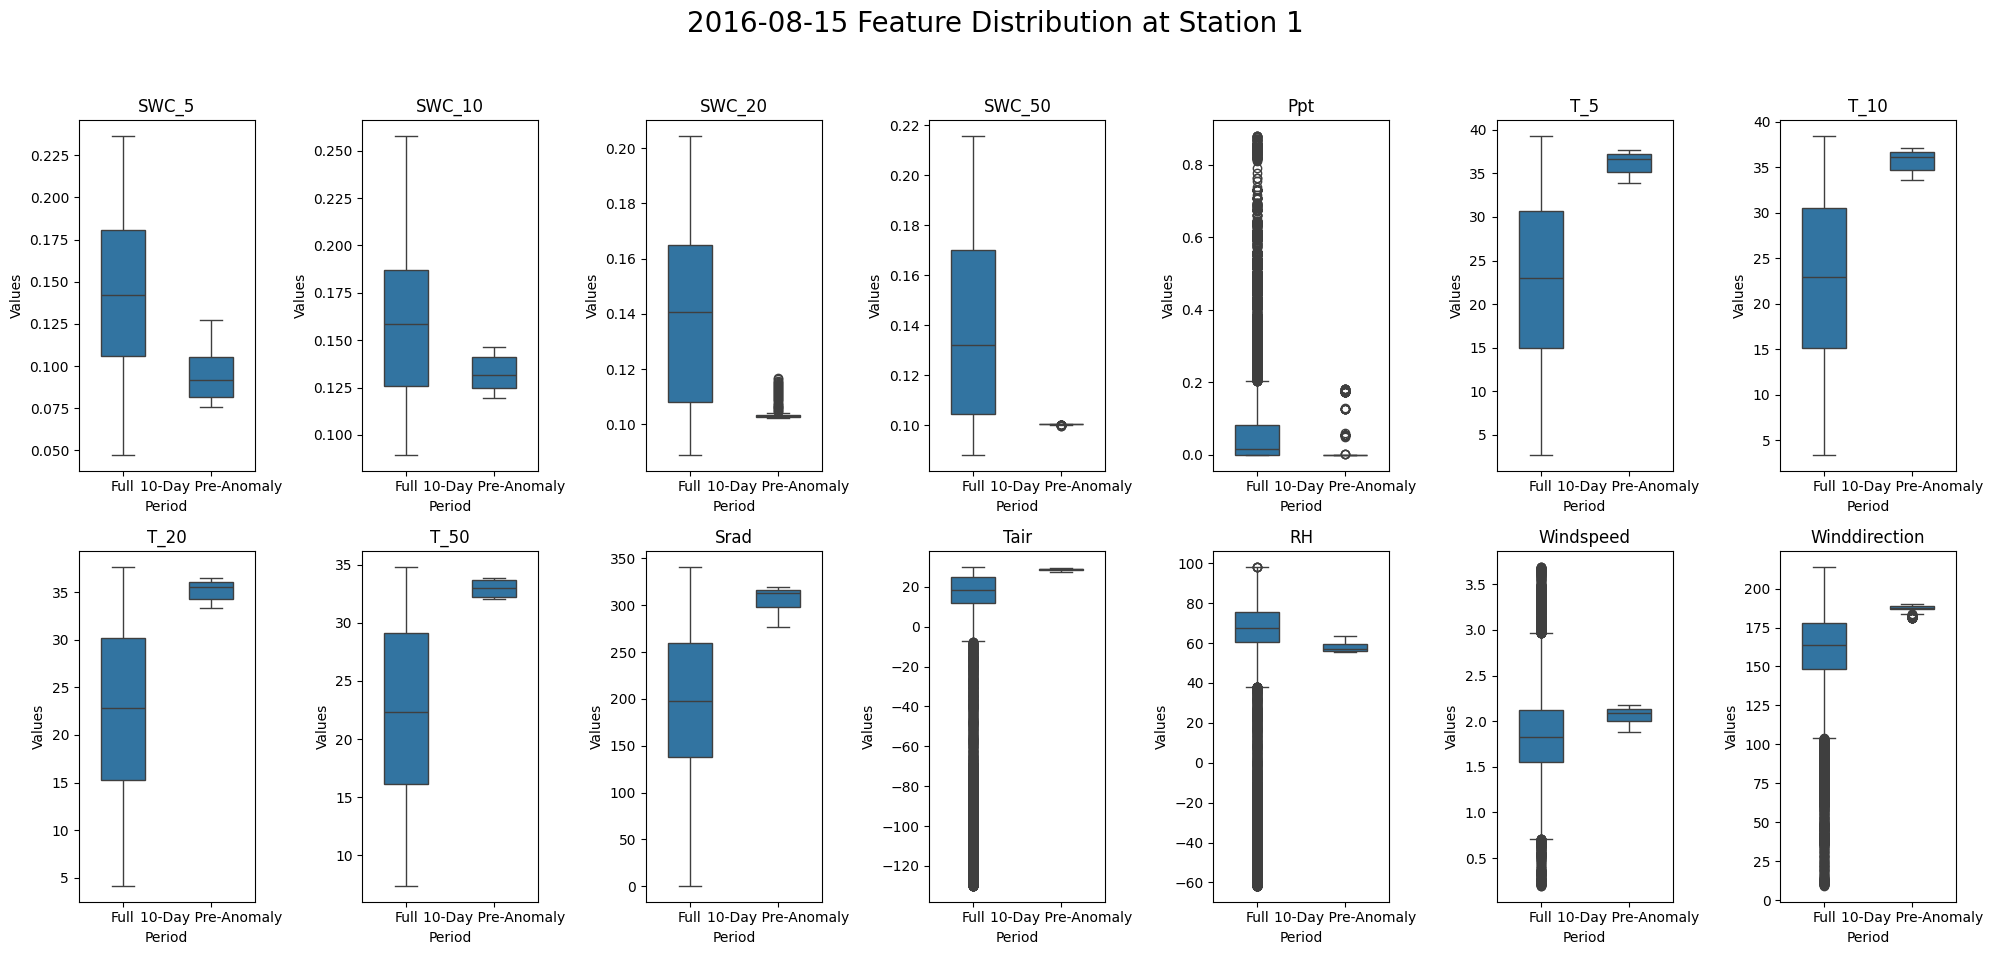

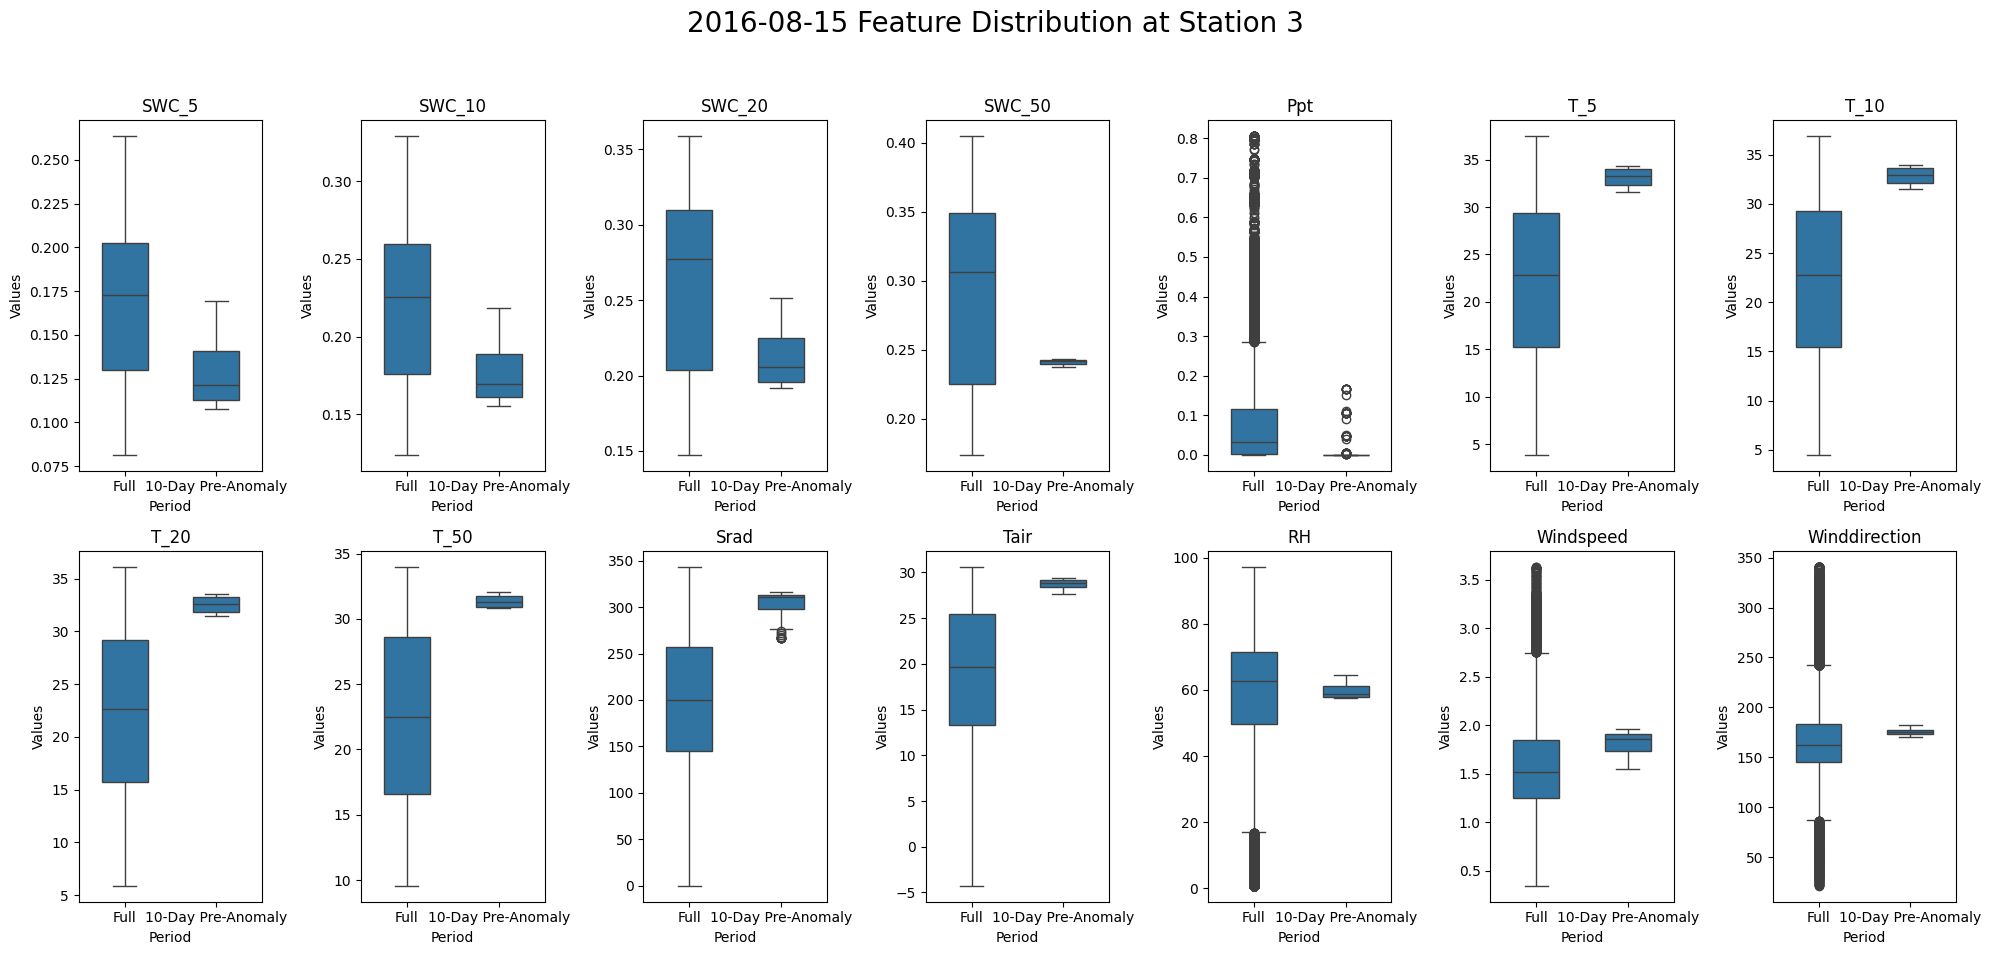

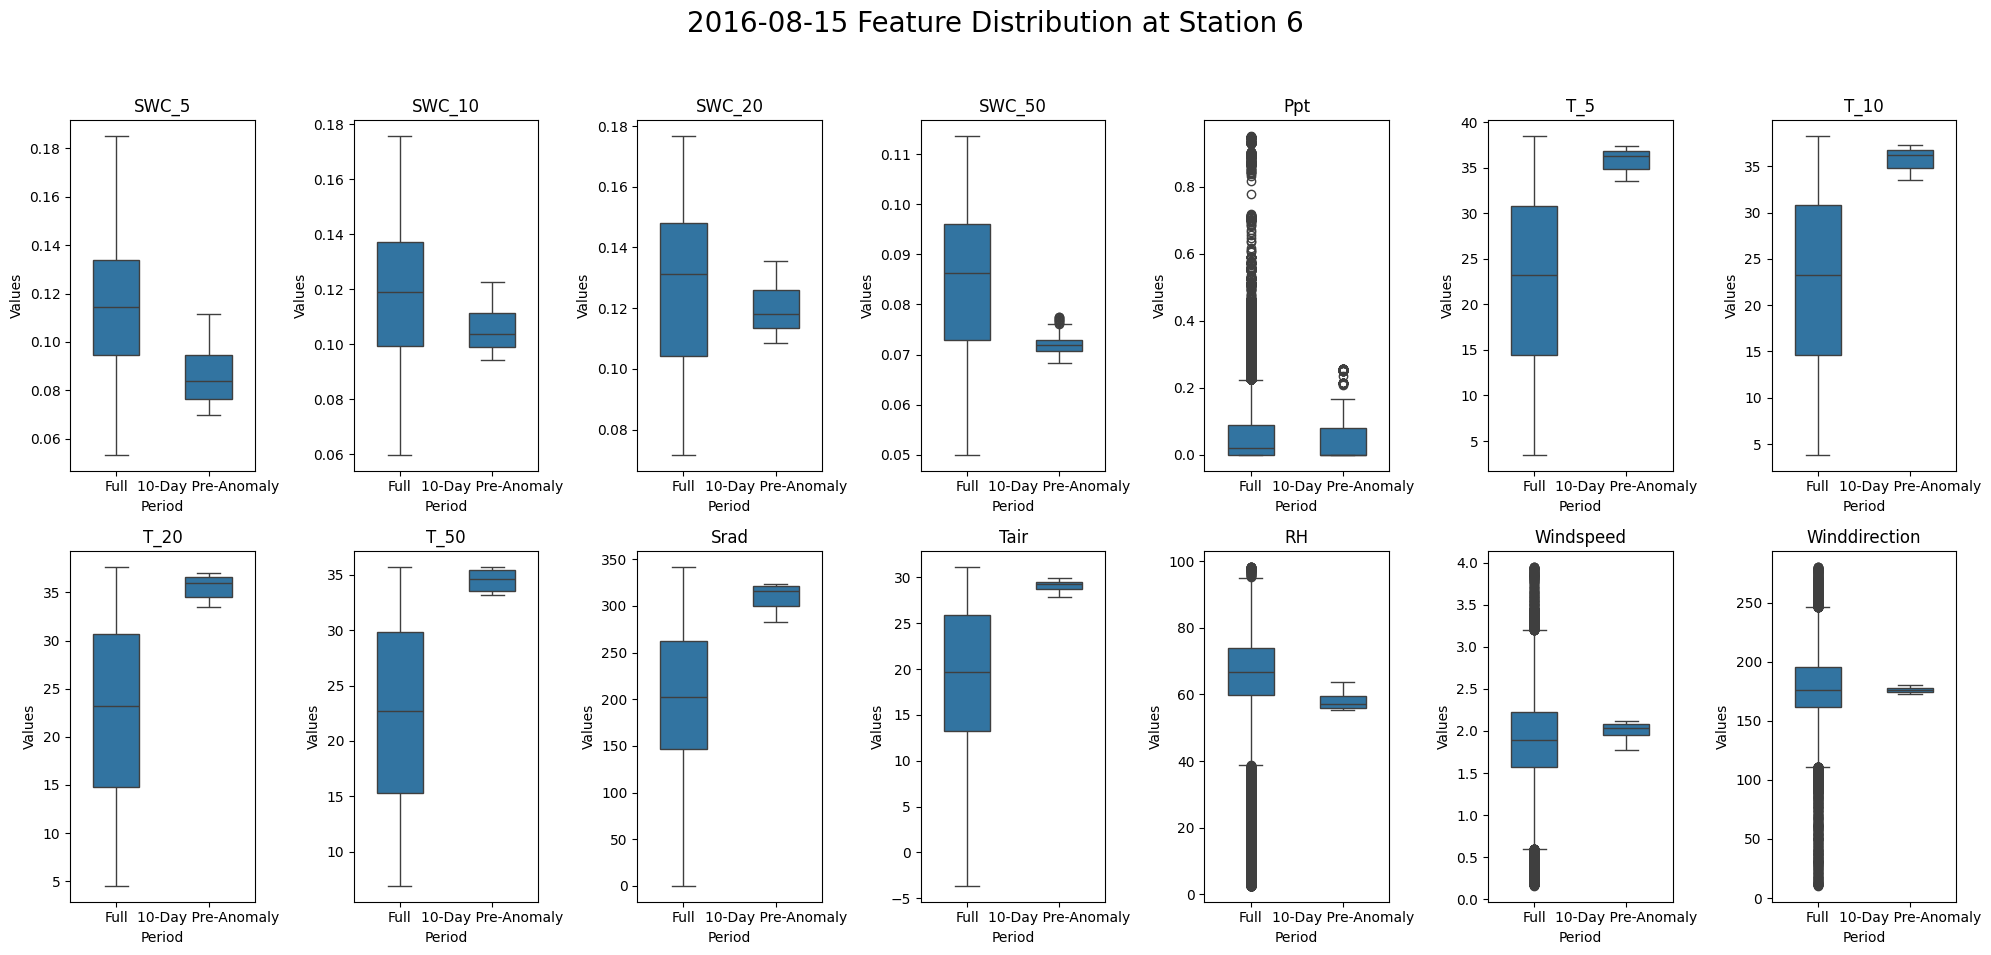

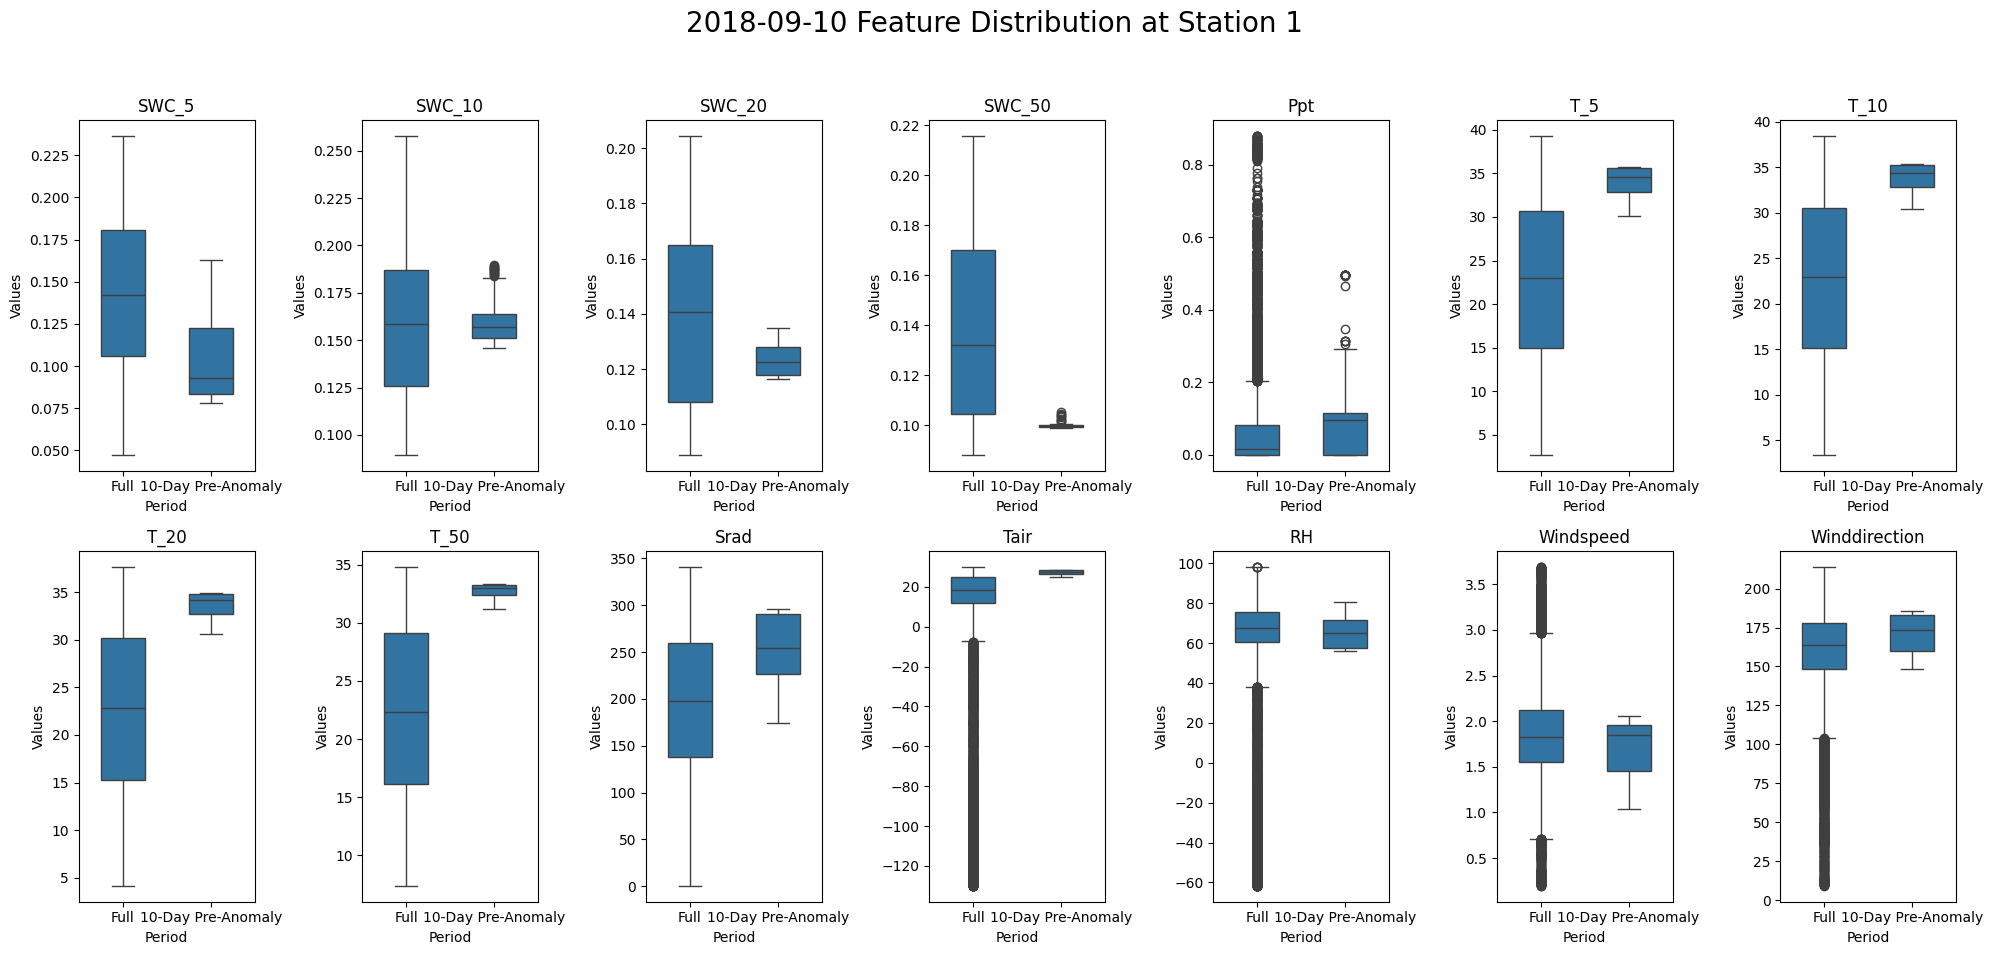

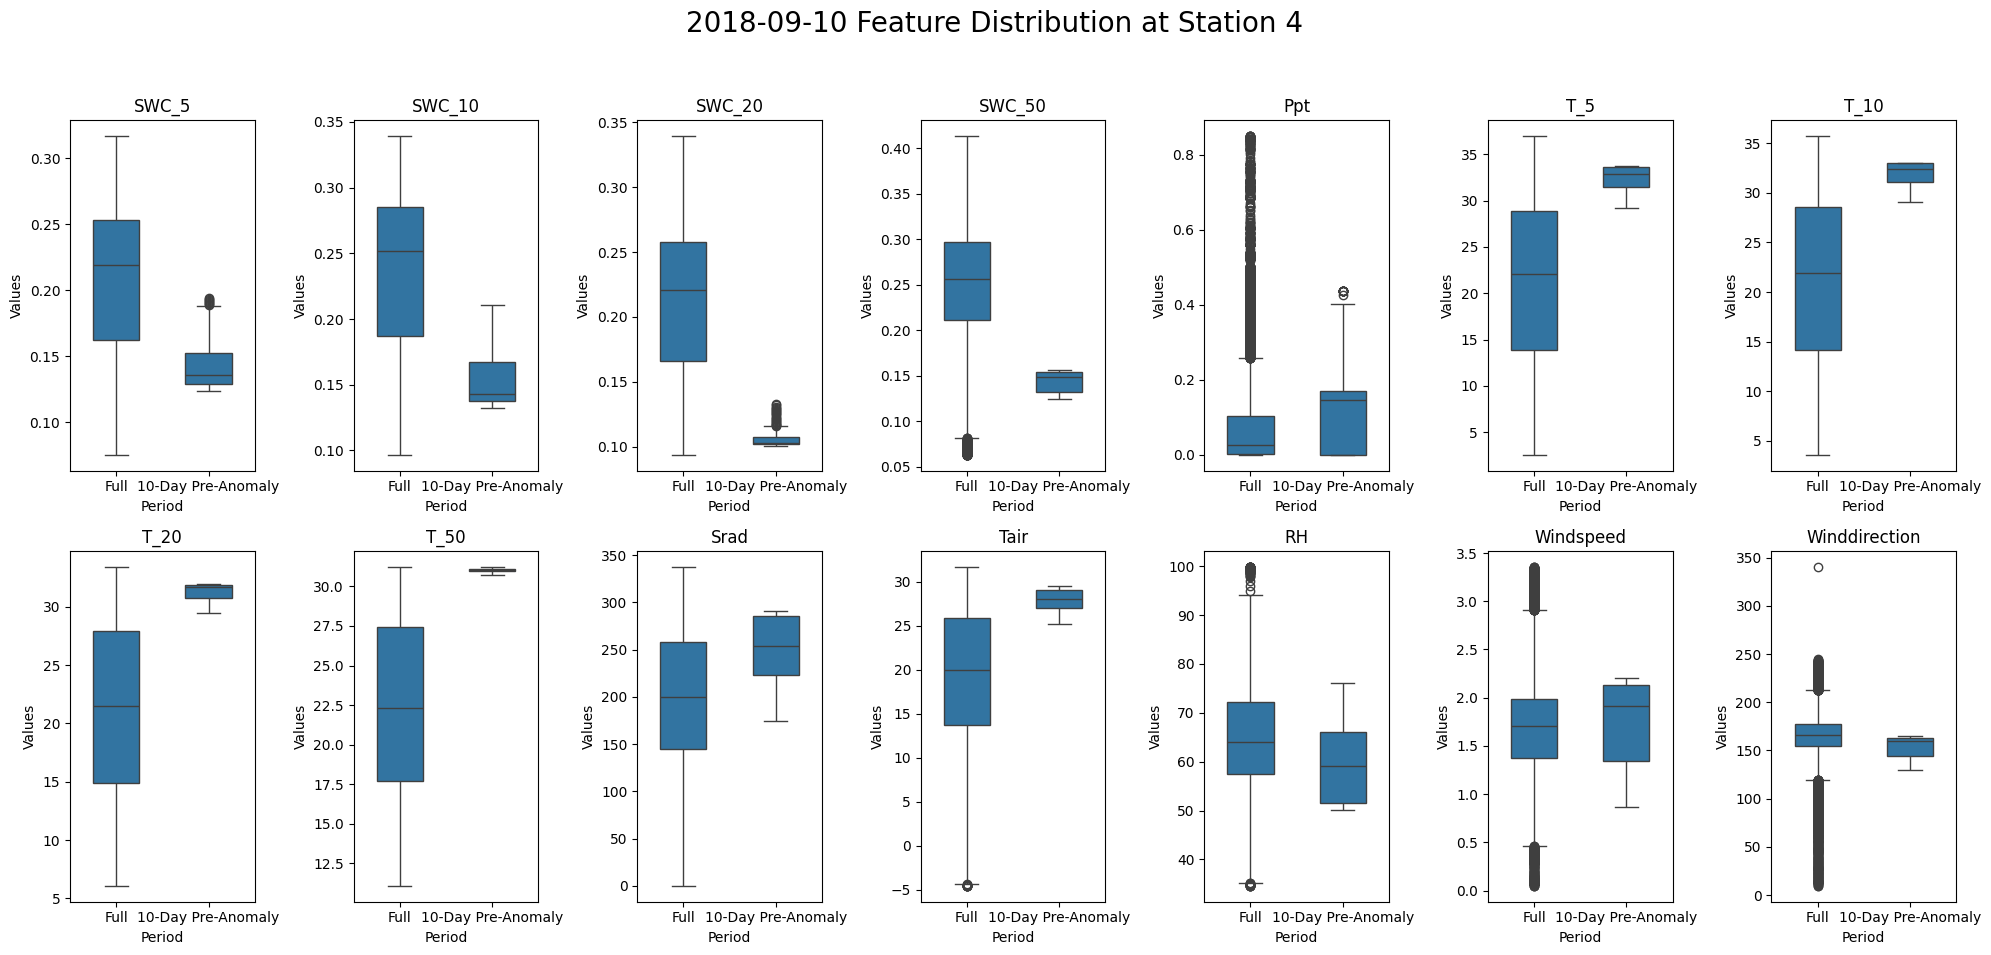

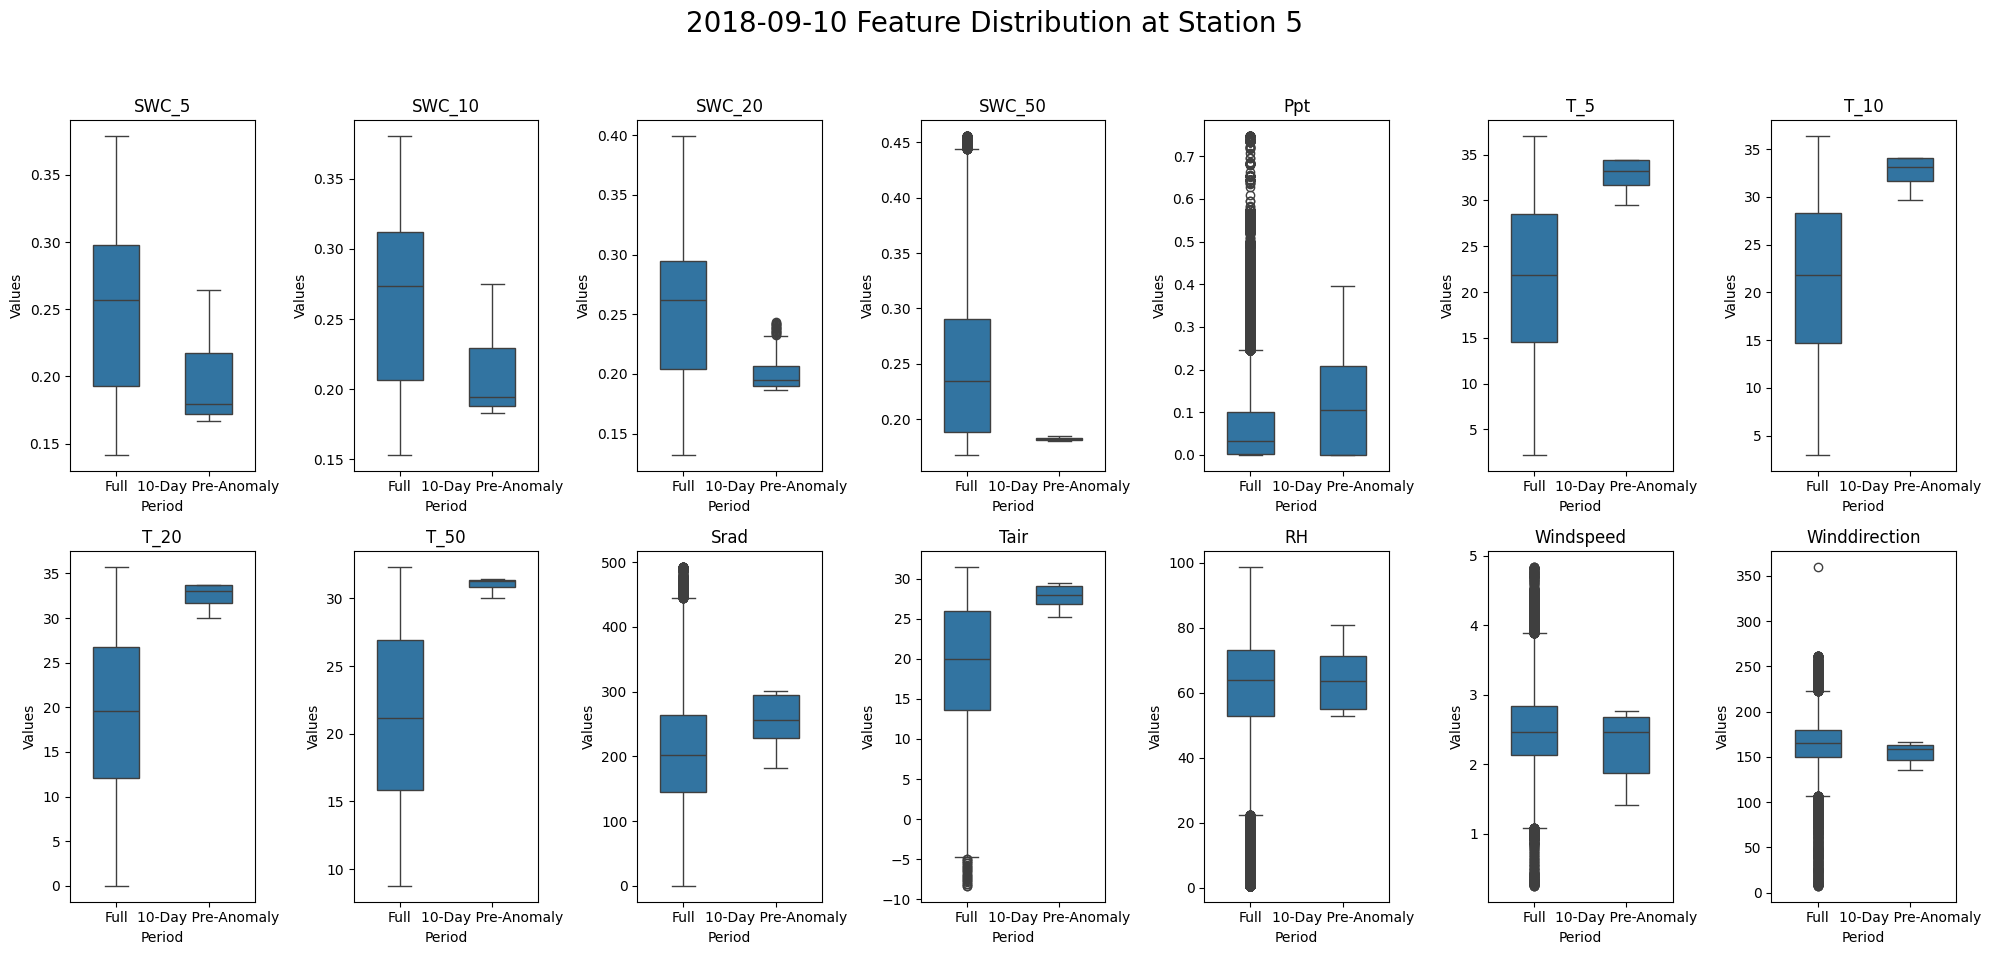

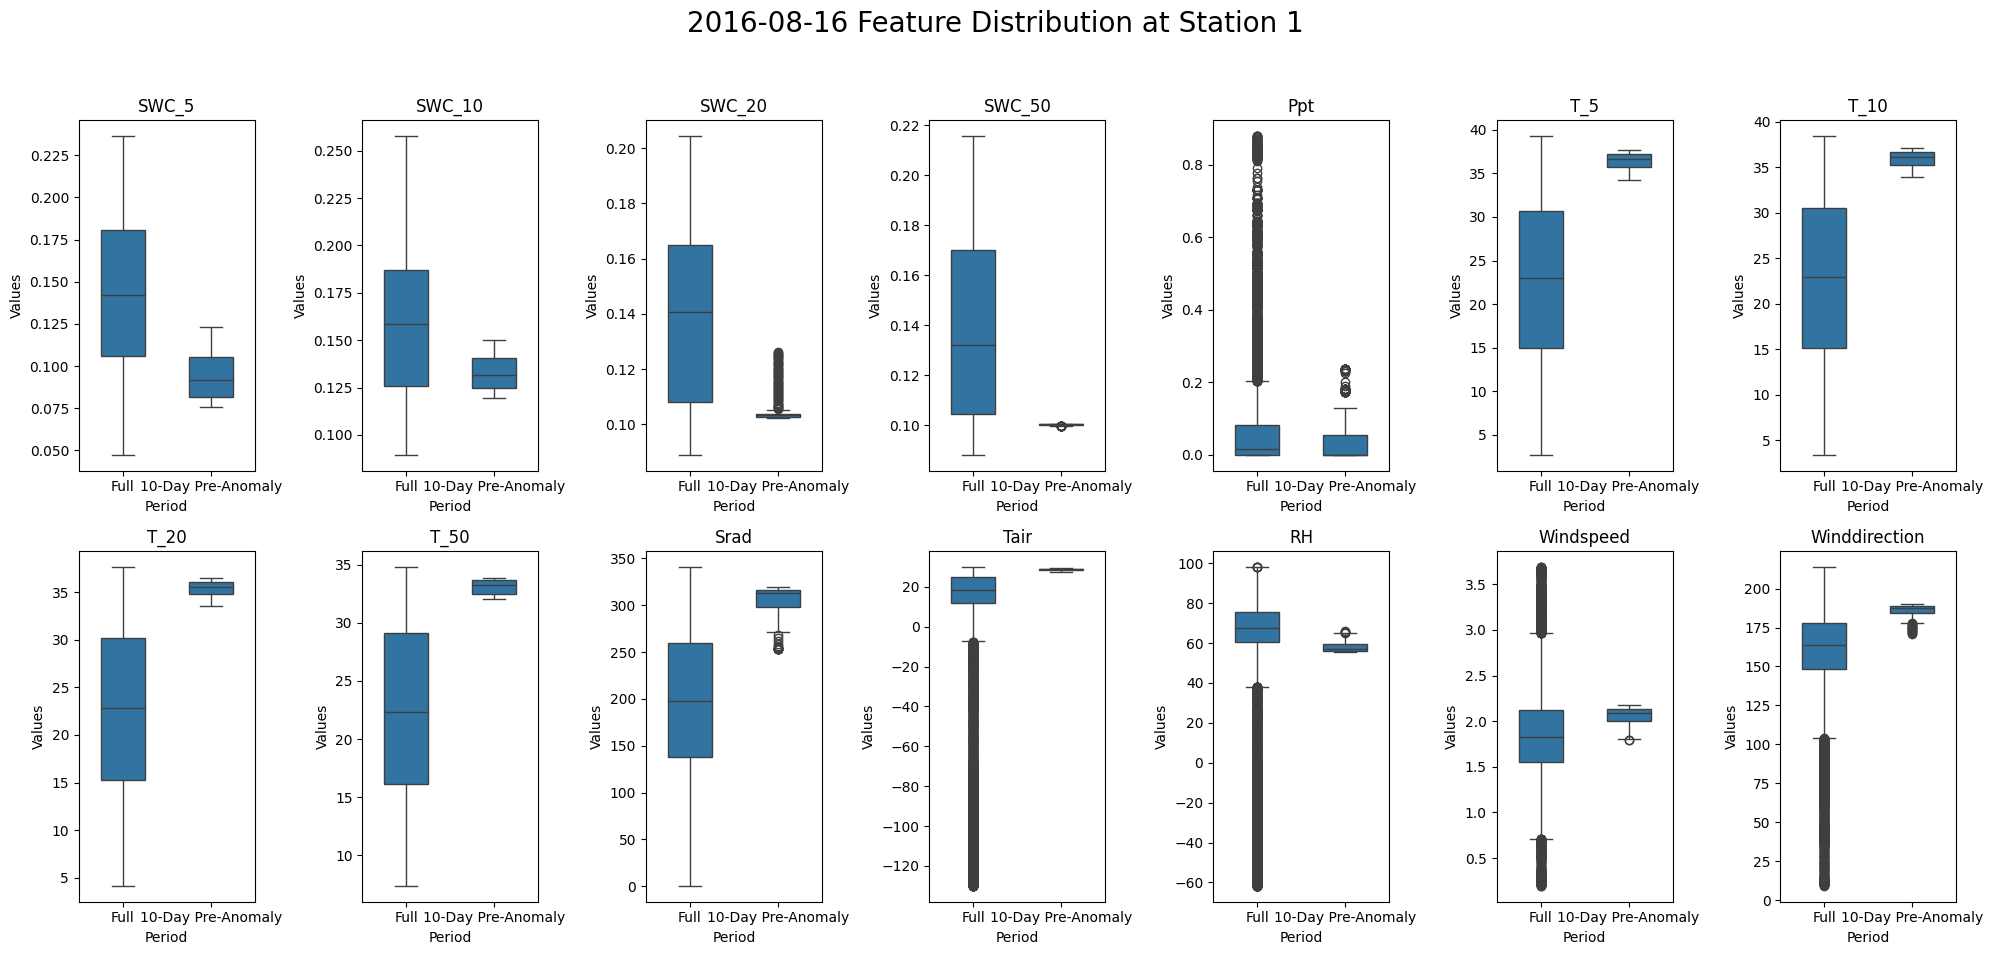

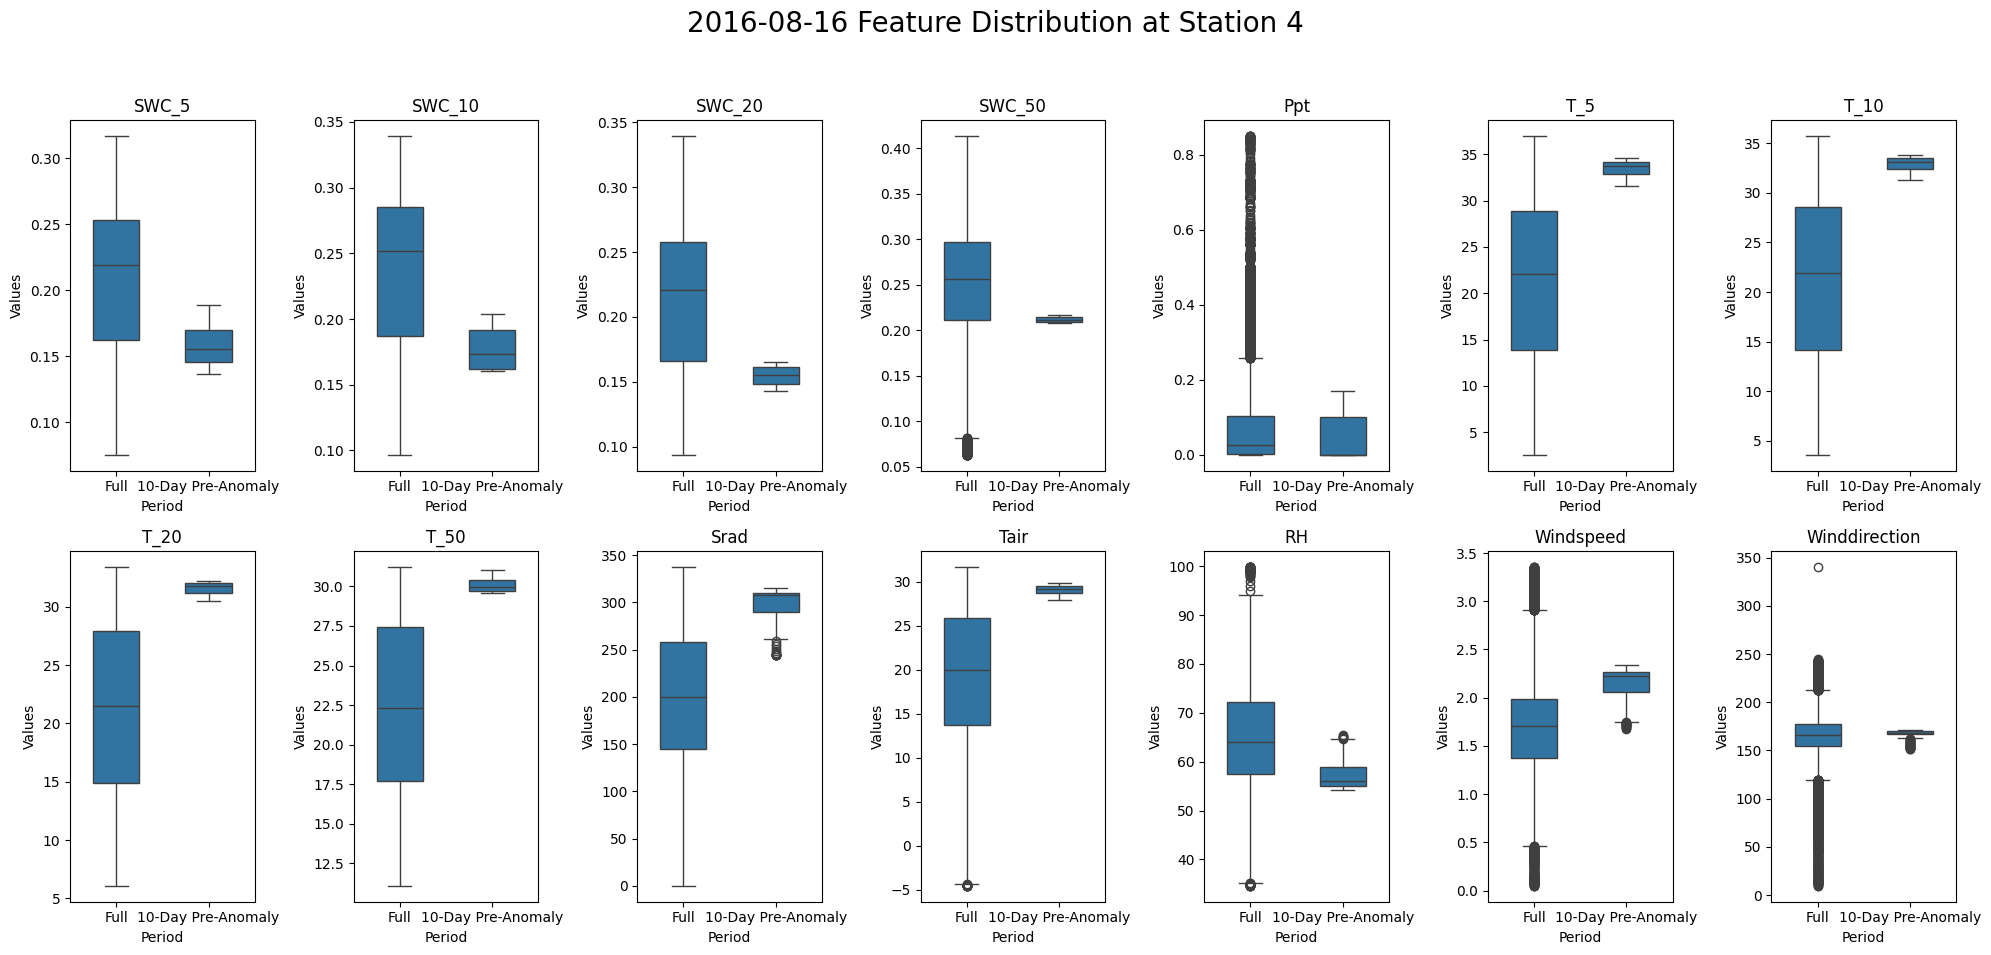

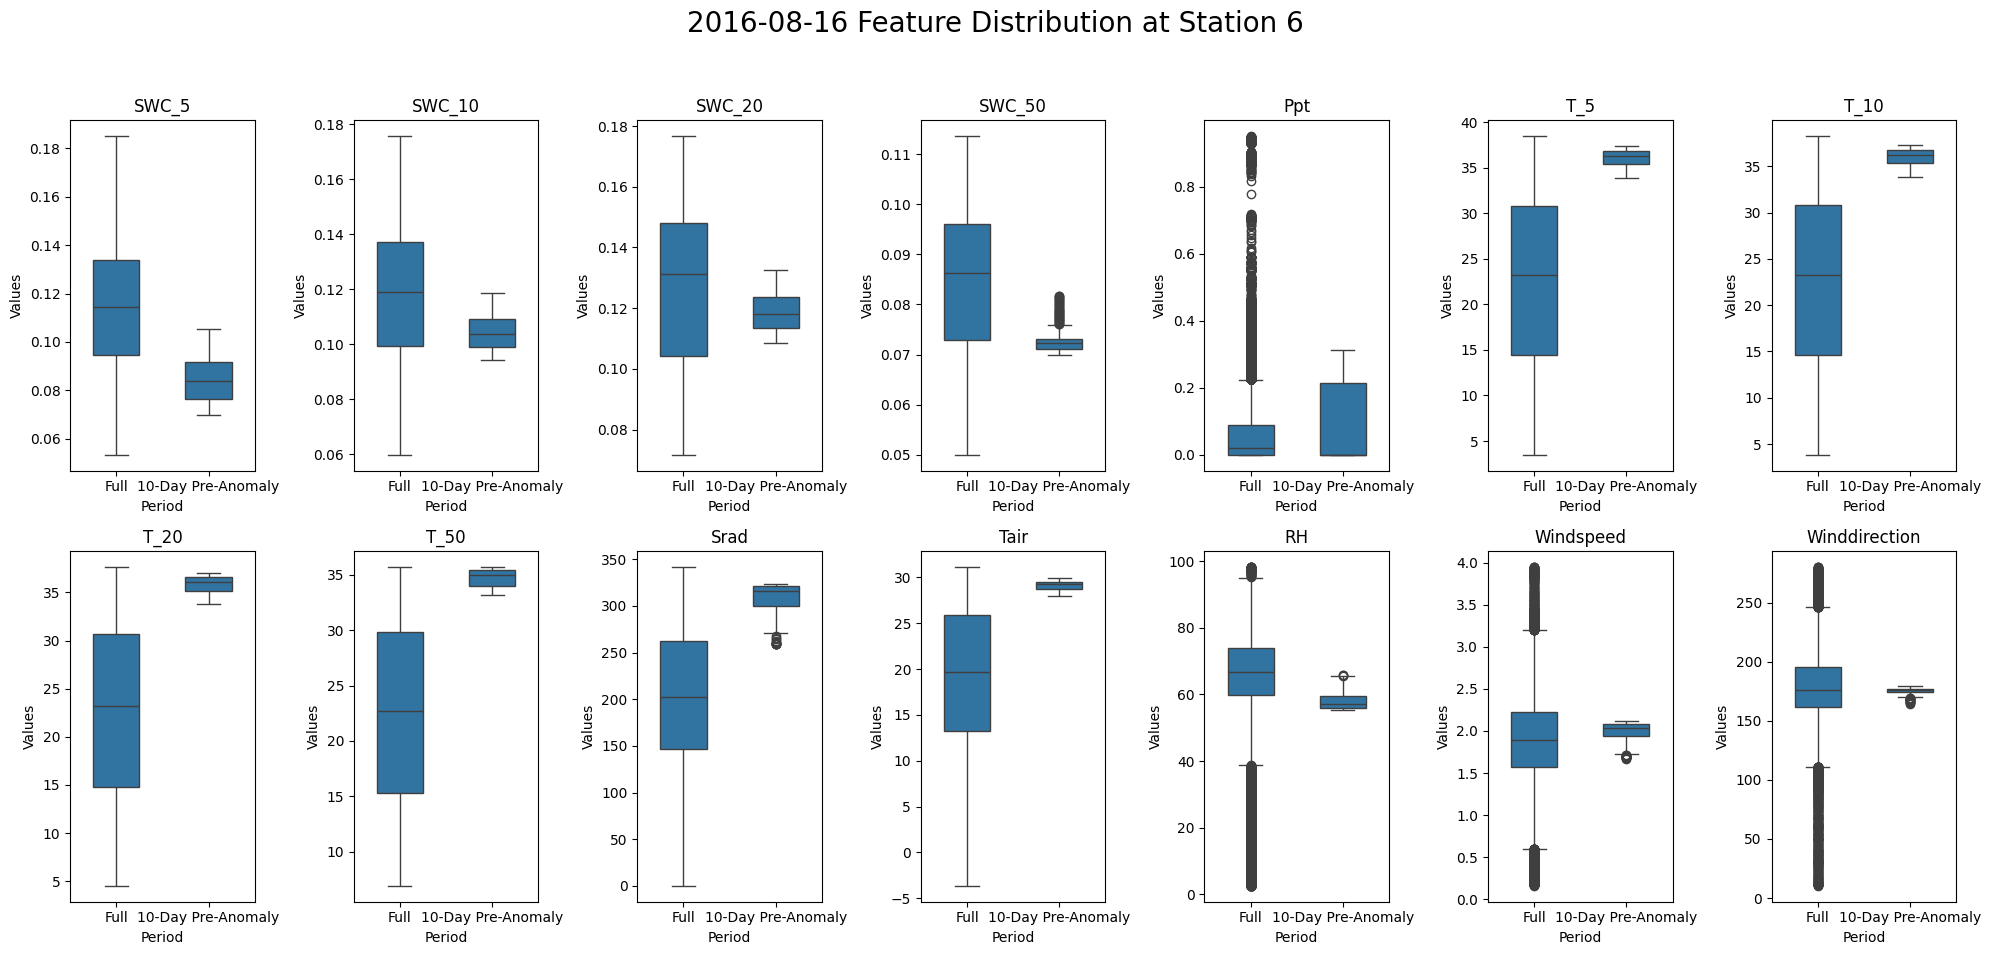

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

common_dates_df = pd.read_csv("SWC_5_Common_Dates_Across_Stations.csv", header= None, skiprows = 1, names=['Description', 'Date', 'Count'])
max_count = common_dates_df['Count'].max()
dates_with_max_count = common_dates_df[common_dates_df['Count'] == max_count]['Date']

def plot_feature_distributions(date, feature_tables, station_indices):
    date_time = pd.to_datetime(date)

    for station, feature_table in zip(station_indices, feature_tables):
        start_date = date_time - pd.Timedelta(days=10)
        start_date = max(start_date, feature_table.index.min())

        recent_data = feature_table.loc[start_date : date_time]

        fig, axs = plt.subplots(nrows = 2, ncols = 7, figsize = (20, 10))
        fig.suptitle(f'{date_time.strftime("%Y-%m-%d")} Feature Distribution at Station {station}', fontsize = 20)

        for idx, feature in enumerate(corr_features):
            feature_col = f'{feature}_Station{station}'

            full_data = feature_table[feature_col].dropna()
            recent_data_feature = recent_data[feature_col].dropna()

            if recent_data_feature.empty:
                continue

            data_to_plot = pd.DataFrame({
                'Values': pd.concat([full_data, recent_data_feature]),
                'Period': ['Full']*len(full_data) + ['10-Day Pre-Anomaly'] * len(recent_data_feature)
            })

            ax = axs[idx // 7, idx % 7]

            sns.boxplot(x = 'Period', y = 'Values', data=data_to_plot, width = 0.5, ax = ax)
            ax.set_title(feature)
            ax.set_ylabel('Values')

        plt.tight_layout(rect = [0, 0.03, 1, 0.95])
        plt.show()

def check_and_plot(dates, feature_tables):
    for date in dates:
        date_presence = [False] * len(feature_tables)
        station_indices = []
        for i in range(len(feature_tables)):
            station = i + 1
            anomaly_df = pd.read_csv(f"SWC_5_Station_{station}_High_Frequency_Anomalies.csv", header = None, names = ['Date'], skiprows = 1)
            anomaly_df['Date'] = pd.to_datetime(anomaly_df['Date'], format = '%m-%d-%Y')
            if pd.to_datetime(date) in anomaly_df['Date'].values:
                date_presence[i] = True
                station_indices.append(station)

        if any(date_presence):
            selected_tables = [feature_tables[i] for i in range(len(date_presence)) if date_presence[i]]
            plot_feature_distributions(date, selected_tables, station_indices)

max_count_dates = common_dates_df[common_dates_df['Count'] == max_count]['Date']
check_and_plot(max_count_dates, corr_feature_tables)

## Ppt Feature Distribution Analysis ##

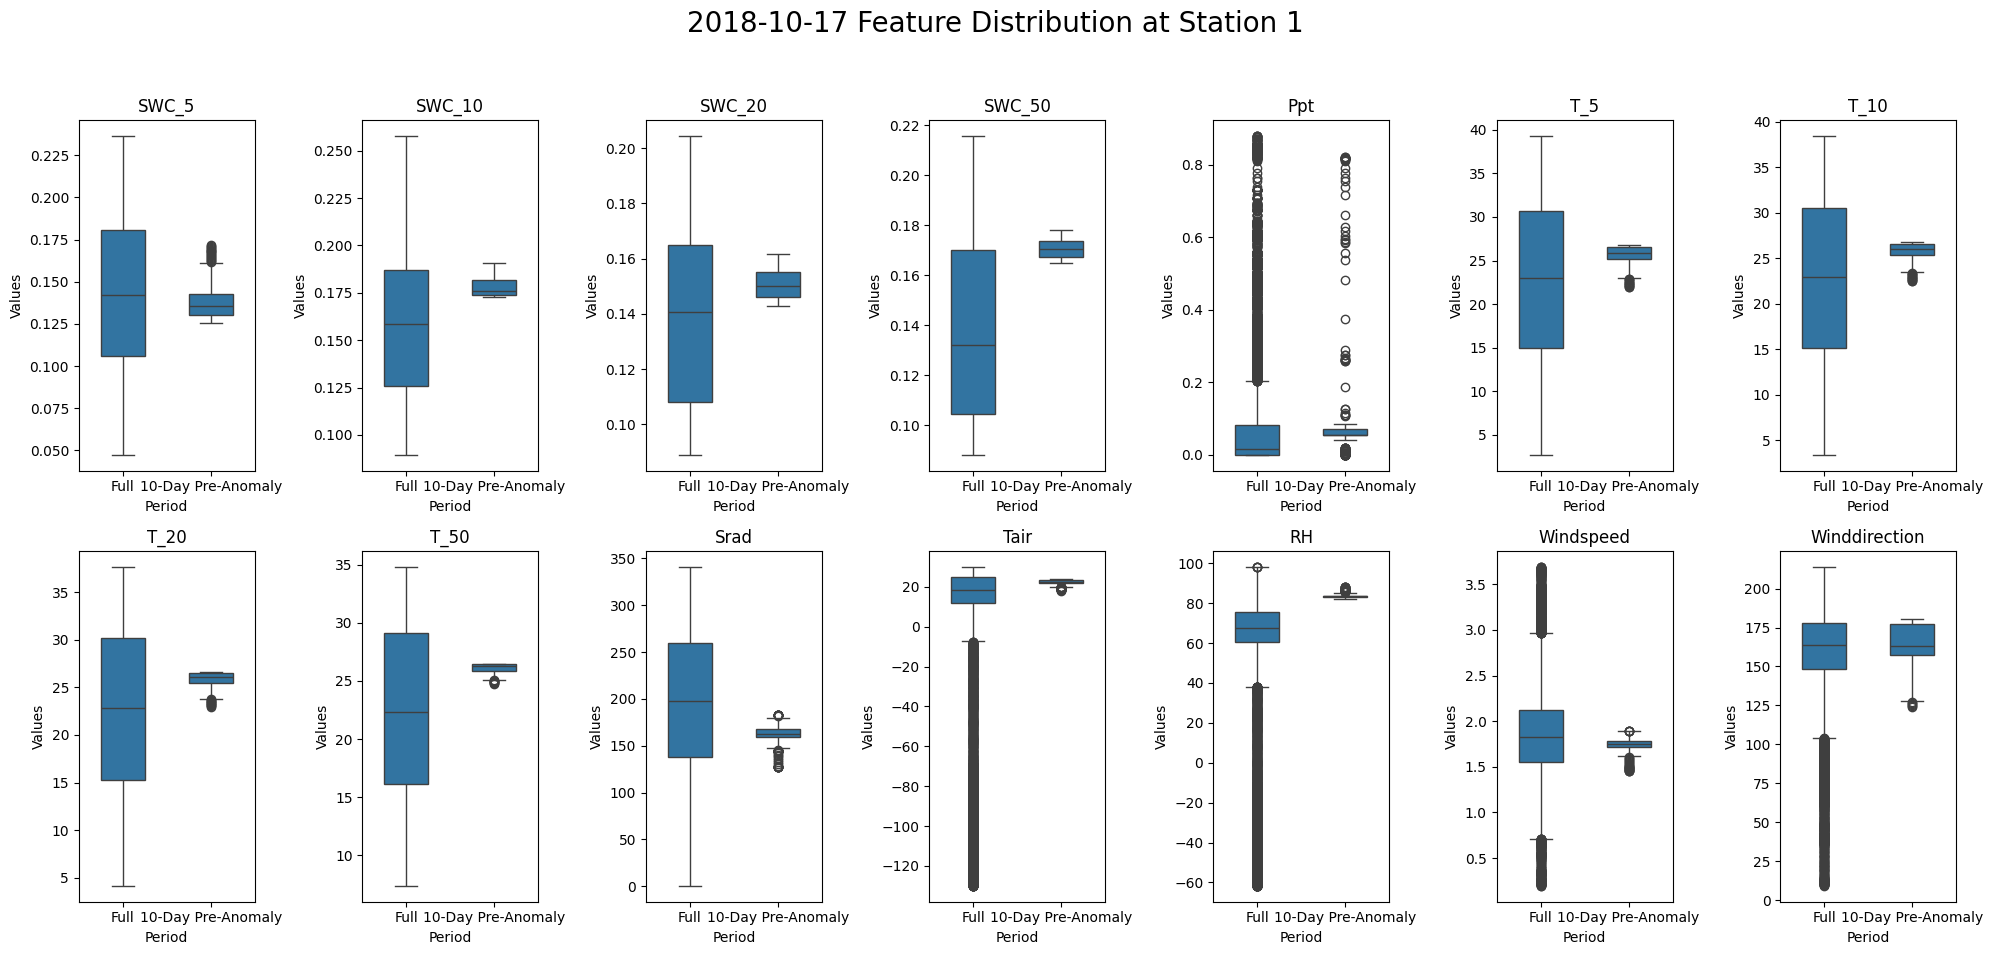

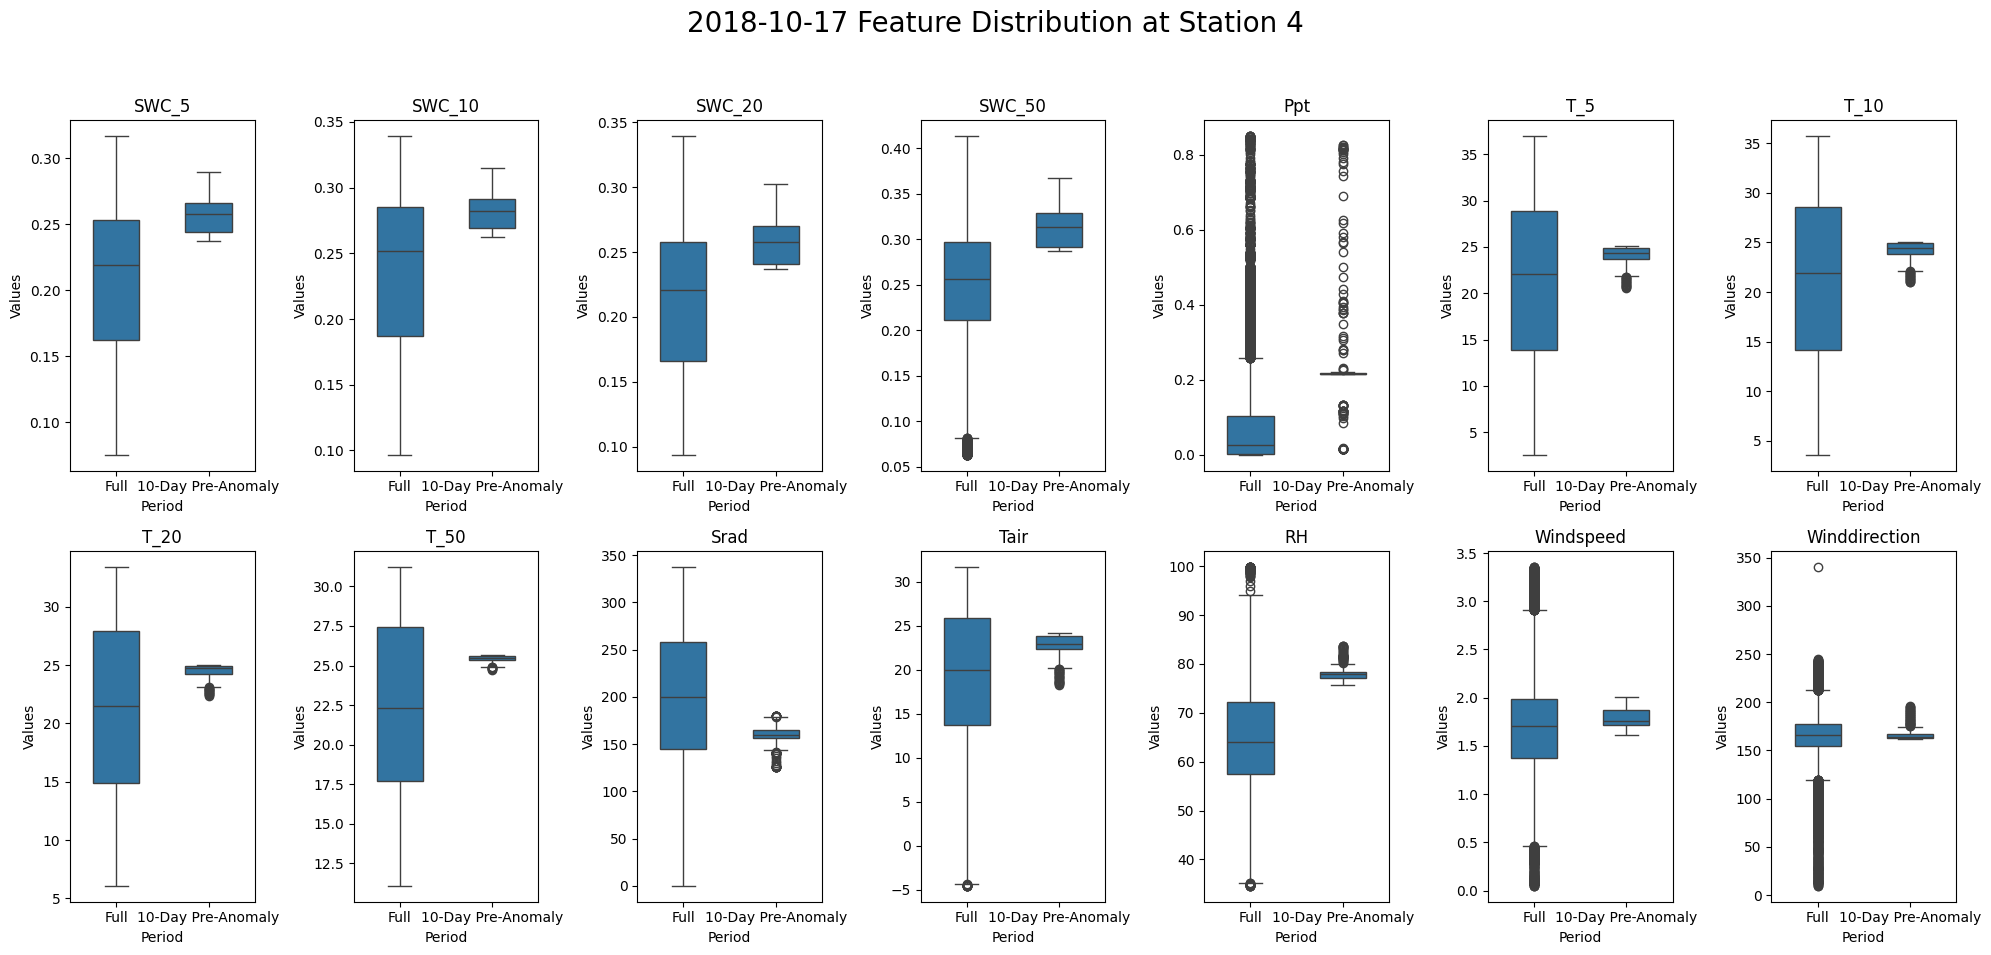

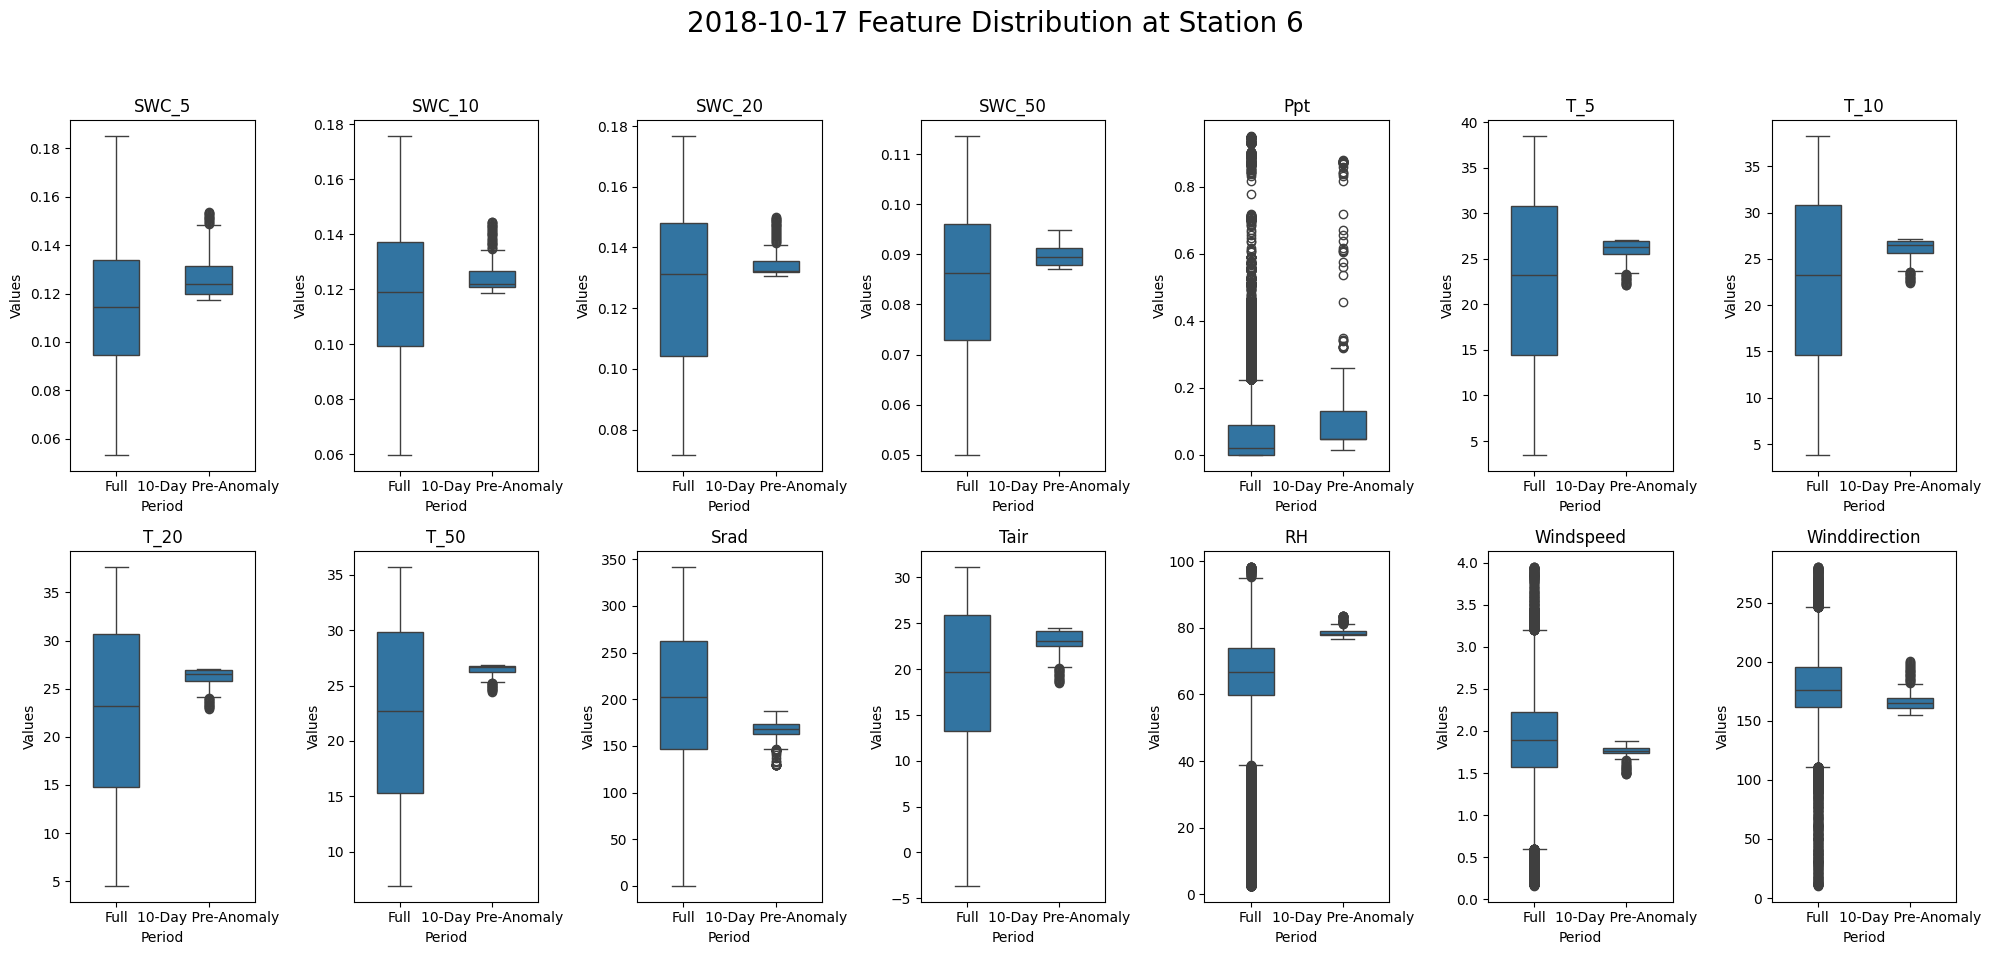

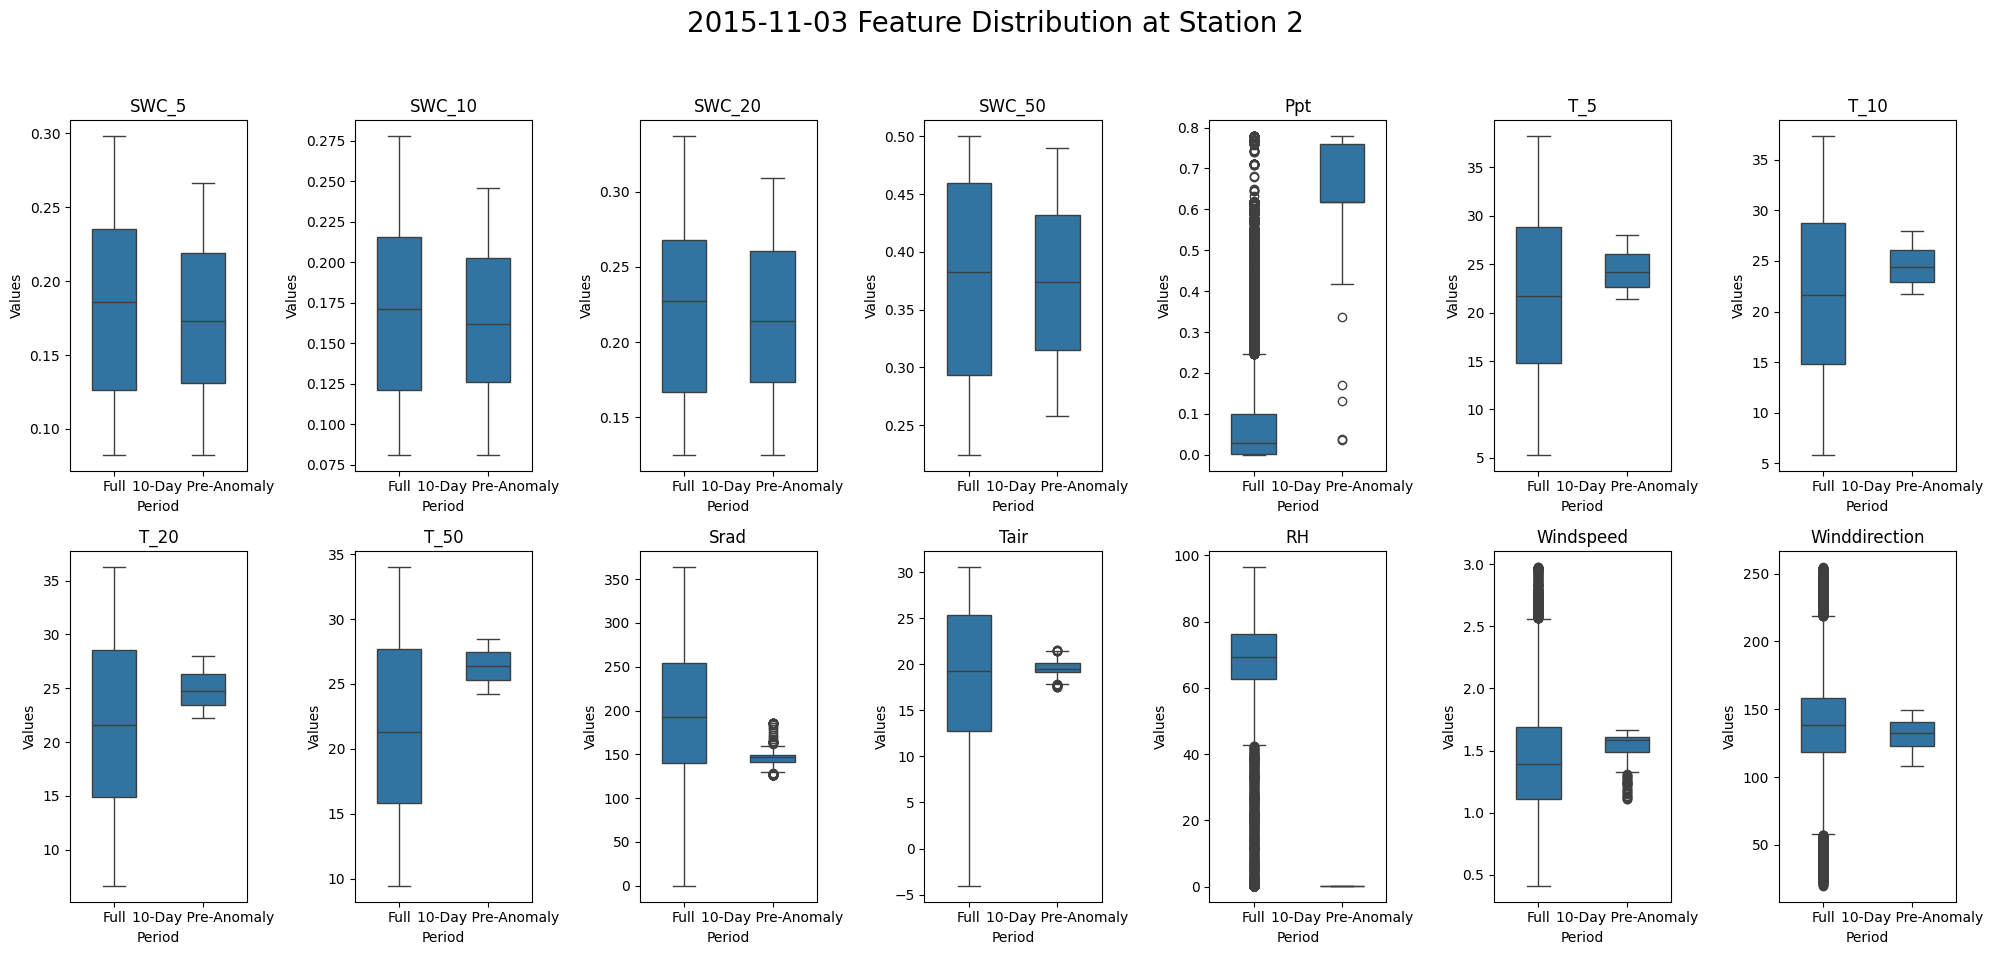

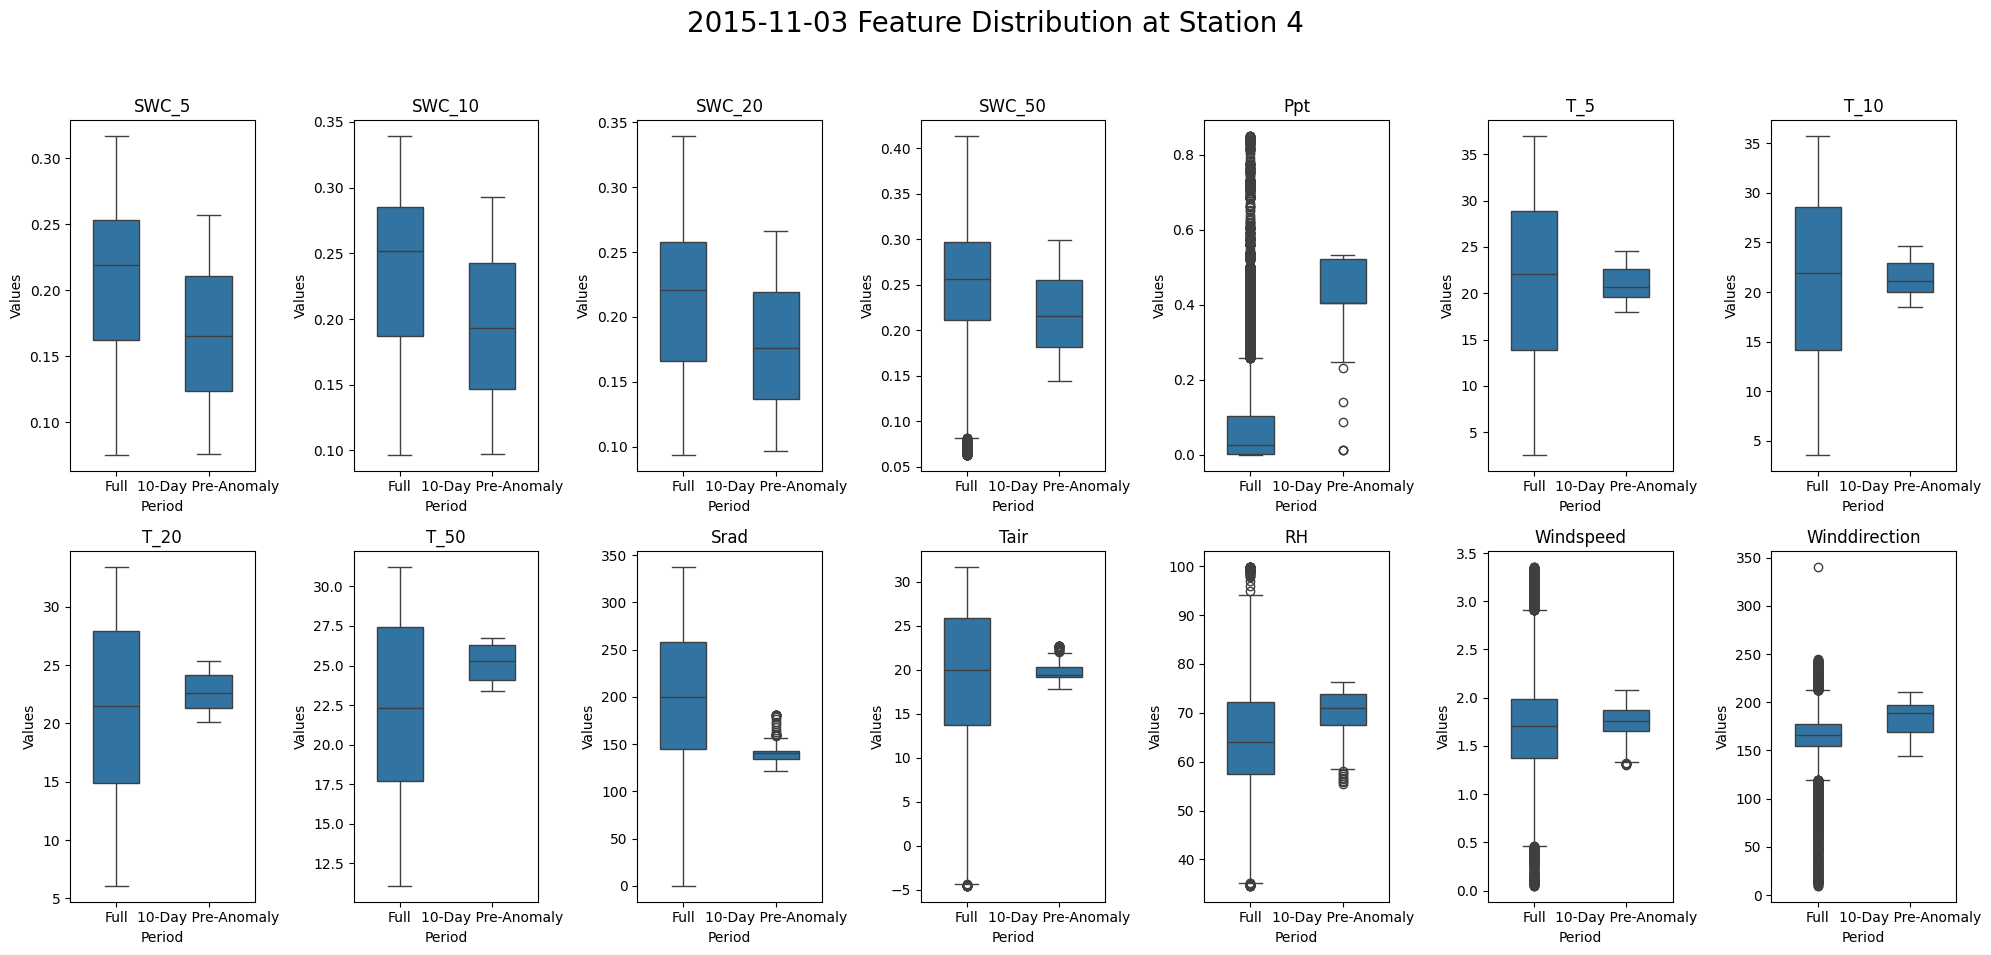

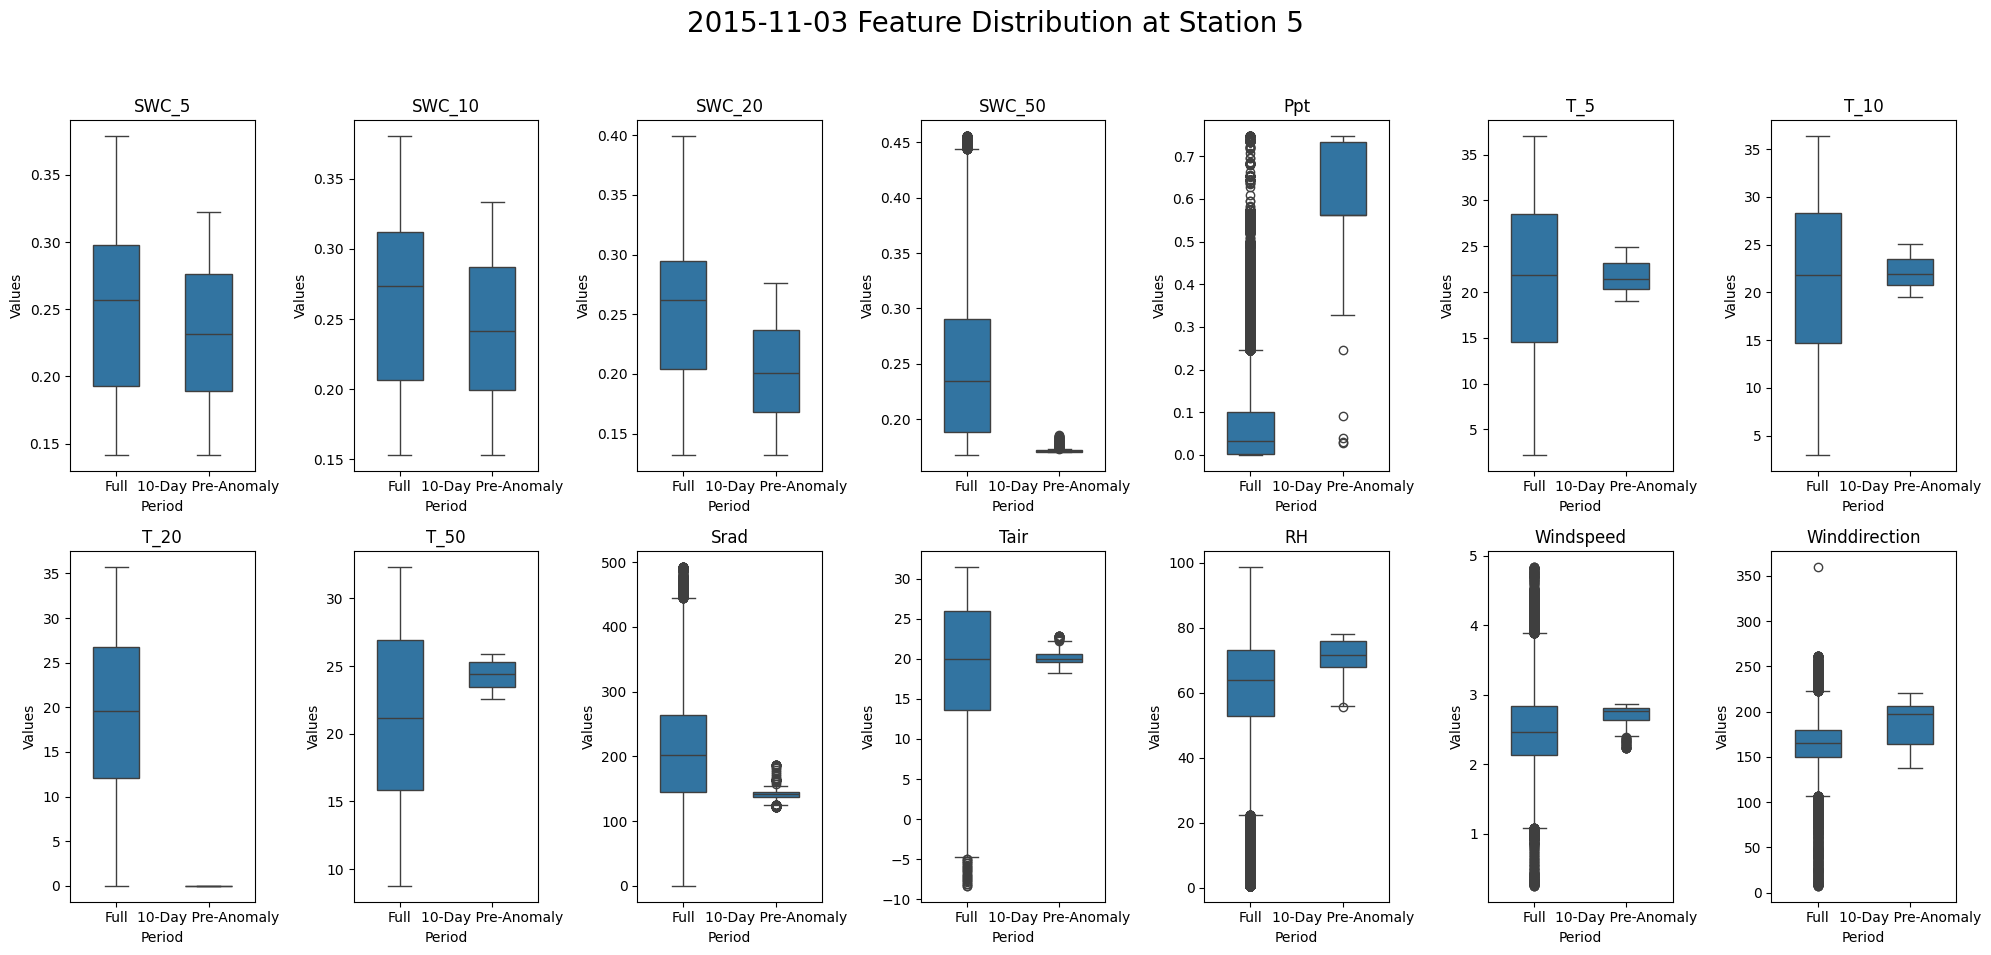

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

common_dates_df = pd.read_csv("Ppt_Common_Dates_Across_Stations.csv", header= None, skiprows = 1, names=['Description', 'Date', 'Count'])
max_count = common_dates_df['Count'].max()
dates_with_max_count = common_dates_df[common_dates_df['Count'] == max_count]['Date']

def plot_feature_distributions(date, feature_tables, station_indices):
    date_time = pd.to_datetime(date)

    for station, feature_table in zip(station_indices, feature_tables):
        start_date = date_time - pd.Timedelta(days=10)
        start_date = max(start_date, feature_table.index.min())

        recent_data = feature_table.loc[start_date : date_time]

        fig, axs = plt.subplots(nrows = 2, ncols = 7, figsize = (20, 10))
        fig.suptitle(f'{date_time.strftime("%Y-%m-%d")} Feature Distribution at Station {station}', fontsize = 20)

        for idx, feature in enumerate(corr_features):
            feature_col = f'{feature}_Station{station}'

            full_data = feature_table[feature_col].dropna()
            recent_data_feature = recent_data[feature_col].dropna()

            if recent_data_feature.empty:
                continue

            data_to_plot = pd.DataFrame({
                'Values': pd.concat([full_data, recent_data_feature]),
                'Period': ['Full']*len(full_data) + ['10-Day Pre-Anomaly'] * len(recent_data_feature)
            })

            ax = axs[idx // 7, idx % 7]

            sns.boxplot(x = 'Period', y = 'Values', data=data_to_plot, width = 0.5, ax = ax)
            ax.set_title(feature)
            ax.set_ylabel('Values')

        plt.tight_layout(rect = [0, 0.03, 1, 0.95])
        plt.show()

def check_and_plot(dates, feature_tables):
    for date in dates:
        date_presence = [False] * len(feature_tables)
        station_indices = []
        for i in range(len(feature_tables)):
            station = i + 1
            anomaly_df = pd.read_csv(f"Ppt_Station_{station}_High_Frequency_Anomalies.csv", header = None, names = ['Date'], skiprows = 1)
            anomaly_df['Date'] = pd.to_datetime(anomaly_df['Date'], format = '%m-%d-%Y')
            if pd.to_datetime(date) in anomaly_df['Date'].values:
                date_presence[i] = True
                station_indices.append(station)

        if any(date_presence):
            selected_tables = [feature_tables[i] for i in range(len(date_presence)) if date_presence[i]]
            plot_feature_distributions(date, selected_tables, station_indices)

max_count_dates = common_dates_df[common_dates_df['Count'] == max_count]['Date']
check_and_plot(max_count_dates, corr_feature_tables)